# Quantum Simulation of Photo-Induced Charge Dynamics: Ethylene

**Track 1 — VQE + Quantum Subspace Expansion for ground and excited states of ethylene.**

| § | Core task | What is produced |
|---|---|---|
| 1 | Molecular setup | Hamiltonians at 0° and 90° torsion, 2e/2o and 2e/4o, STO-3G, JW / parity / Z₂-tapered mappings |
| 2 | Ground-state VQE | UCCSD and hardware-efficient ansätze, three optimizers, convergence + qubit count + **transpiled** depth |
| 3 | Excited states via QSE | Excitation-operator subspace, regularized generalized eigenproblem, π→π\* energy, roots labelled by ⟨N⟩, ⟨S²⟩ and oscillator strength; singles vs. singles+doubles (the genuine truncation test is on butadiene in §6.3) |
| 4 | Noise-aware benchmarking | Real-device noise model, explicit shot-based measurement layer, readout mitigation **and** zero-noise extrapolation |
| 5 | Classical benchmarking | CASCI, CASSCF, EOM-CCSD; basis-set and active-space convergence ladders |
| 6 | Extension / vision | Marcus theory + Generalized Mulliken–Hush from QSE transition densities, embedding path, resource estimate, butadiene toy demo |

---

### The two geometries

- **Planar D₂ₕ (0°)** — weakly correlated and single-reference. Hartree–Fock is a
  good starting point and classical methods behave.
- **Twisted D₂d (90°)** — the two p orbitals become orthogonal, π and π\* become
  degenerate, and the molecule turns **diradicaloid**. The HF determinant is a poor
  reference, the ground state acquires large doubly-excited character, and
  single-reference classical methods degrade, and where the active-space ground
  state becomes a **triplet**.

---
# Setup

In [128]:
!pip install -q \
    "qiskit==2.5.2" \
    "qiskit-nature==0.8.0" \
    "qiskit-algorithms==0.4.0" \
    "qiskit-aer==0.17.2" \
    "qiskit-ibm-runtime==0.49.0" \
    "pyscf==2.14.0"

In [129]:
import json, math, time, warnings, itertools, os
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import scipy
from scipy.optimize import minimize
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector, Pauli

import qiskit_nature
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import NumPyMinimumEigensolver

import pyscf
from pyscf import gto, scf, mcscf, cc

warnings.filterwarnings("ignore")
np.set_printoptions(precision=6, suppress=True, linewidth=140)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.facecolor": "white"})

HARTREE_TO_EV = 27.211386245988
CHEMICAL_ACCURACY_HA = 1.5936e-3
EXPT_PI_PISTAR_EV = 7.66
EXPT_TRIPLET_EV = 4.36

RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)
FIGURES = Path("figures"); FIGURES.mkdir(exist_ok=True)
SEED = 42
rng = np.random.default_rng(SEED)
STORE = {}

print("qiskit        ", qiskit.__version__)
print("qiskit-nature ", qiskit_nature.__version__)
print("pyscf         ", pyscf.__version__)
print("numpy         ", np.__version__)
print("scipy         ", scipy.__version__)

qiskit         2.5.2
qiskit-nature  0.8.0
pyscf          2.14.0
numpy          2.1.3
scipy          1.16.3


---
# 1 — Molecular setup

Ethylene is built from internal coordinates so the torsion is an exact, controlled
parameter. The C=C bond lies along *z*; the C1 methylene sits in the *xz* plane and
the C2 methylene is rotated by the torsion angle about *z*.

In [136]:
CC_BOND, CH_BOND, HCH_ANGLE = 1.339, 1.086, 117.6     # Angstrom, Angstrom, degrees

def ethylene(torsion_deg=0.0, cc=CC_BOND, ch=CH_BOND, hch_deg=HCH_ANGLE):
    tau = math.radians(torsion_deg)
    hcc = math.radians(180.0 - hch_deg / 2.0)
    r = ch * math.sin(hcc)
    z = ch * math.cos(hcc)
    half = cc / 2.0
    atoms = [
        ("C", (0.0, 0.0, -half)),
        ("C", (0.0, 0.0, +half)),
        ("H", (+r, 0.0, -half + z)),
        ("H", (-r, 0.0, -half + z)),
        ("H", (+r * math.cos(tau), +r * math.sin(tau), +half - z)),
        ("H", (-r * math.cos(tau), -r * math.sin(tau), +half - z)),
    ]
    return "; ".join(f"{s} {x:.10f} {y:.10f} {zz:.10f}" for s, (x, y, zz) in atoms)


def _internals(atom_str):
    P = [np.array([float(v) for v in a.split()[1:]]) for a in atom_str.split(";")]
    c1, c2, h1, h2, h3 = P[0], P[1], P[2], P[3], P[4]
    ang = lambda a, b, c: math.degrees(math.acos(np.clip(
        np.dot(a - b, c - b) / (np.linalg.norm(a - b) * np.linalg.norm(c - b)), -1, 1)))
    axis = (c2 - c1) / np.linalg.norm(c2 - c1)
    perp = lambda p, o: (p - o) - np.dot(p - o, axis) * axis
    u, v = perp(h1, c1), perp(h3, c2)
    tors = math.degrees(math.acos(np.clip(
        np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)), -1, 1)))
    return dict(cc=np.linalg.norm(c2 - c1), ch=np.linalg.norm(h1 - c1),
                hch=ang(h1, c1, h2), hcc=ang(h1, c1, c2), torsion=tors)


GEOMETRIES = {"equilibrium": ethylene(0.0), "twisted": ethylene(90.0)}

for name, atom in GEOMETRIES.items():
    g = _internals(atom)
    print(f"{name:<12} C=C {g['cc']:.4f} A   C-H {g['ch']:.4f} A   "
          f"HCH {g['hch']:.2f}   HCC {g['hcc']:.2f}   torsion {g['torsion']:.2f}")
    assert abs(g["cc"] - CC_BOND) < 1e-6 and abs(g["ch"] - CH_BOND) < 1e-6
    assert abs(g["hch"] - HCH_ANGLE) < 1e-6
    assert abs(g["torsion"] - float(name == "twisted") * 90.0) < 1e-6

equilibrium  C=C 1.3390 A   C-H 1.0860 A   HCH 117.60   HCC 121.20   torsion 0.00
twisted      C=C 1.3390 A   C-H 1.0860 A   HCH 117.60   HCC 121.20   torsion 90.00


## 1.2 — Hamiltonian construction and qubit mapping

`ActiveSpaceTransformer` selects the *n* spatial orbitals around the Fermi level.
Ethylene in STO-3G has 14 spatial orbitals and 16 electrons, so the HOMO is orbital
index 7 and the LUMO index 8 — the π / π\* pair. A 2e/2o active space therefore
picks exactly the two orbitals the challenge asks for, and PySCF's `CASCI(mf, 2, 2)`
(which defaults to `ncore=7`) picks the same pair.

**On the constant energy shift.** The mapped qubit operator carries only the
active-space electronic energy; the total energy additionally needs the nuclear
repulsion and the inactive (frozen-core) energy. Rather than assembling those
constants by hand — the most common source of a large constant offset at this step —
the shift is *calibrated* by comparing Qiskit Nature's own `GroundStateEigensolver`
total energy against the raw lowest eigenvalue of the mapped operator.

In [137]:
@dataclass
class System:
    """One (geometry, active space) problem plus everything derived from it."""
    label: str
    torsion_deg: float
    n_elec: int
    n_orb: int
    basis: str
    problem: object
    mapper: object
    H_qubit: SparsePauliOp
    H_matrix: np.ndarray
    shift: float
    e_exact: float
    n_qubits: int
    qubit_counts: dict
    n_particles: tuple
    atom: str
    driver: object

    @property
    def key(self):
        return f"{self.label}_{self.n_elec}e{self.n_orb}o"


_DRIVER_CACHE = {}

def get_driver(atom, basis):
    key = (atom, basis)
    if key not in _DRIVER_CACHE:
        driver = PySCFDriver(atom=atom, basis=basis, charge=0, spin=0,
                             unit=DistanceUnit.ANGSTROM)
        _DRIVER_CACHE[key] = (driver, driver.run())
    return _DRIVER_CACHE[key]


def build_system(label, torsion_deg, n_elec=2, n_orb=2, basis="sto3g", atom=None):
    atom = atom if atom is not None else ethylene(torsion_deg)
    driver, full_problem = get_driver(atom, basis)
    problem = ActiveSpaceTransformer(
        num_electrons=n_elec, num_spatial_orbitals=n_orb).transform(full_problem)

    mapper = JordanWignerMapper()
    second_q = problem.hamiltonian.second_q_op()
    H_qubit = mapper.map(second_q)
    H_matrix = np.asarray(H_qubit.to_matrix())

    raw = float(np.linalg.eigvalsh(H_matrix)[0].real)
    total = GroundStateEigensolver(
        mapper, NumPyMinimumEigensolver()).solve(problem).total_energies[0].real
    shift = float(total - raw)

    counts = {"jordan_wigner": H_qubit.num_qubits}
    try:
        counts["parity_2q_reduced"] = ParityMapper(
            num_particles=problem.num_particles).map(second_q).num_qubits
    except Exception as exc:
        counts["parity_2q_reduced"] = f"n/a ({type(exc).__name__})"
    try:
        counts["z2_tapered"] = problem.get_tapered_mapper(
            JordanWignerMapper()).map(second_q).num_qubits
    except Exception as exc:
        counts["z2_tapered"] = f"n/a ({type(exc).__name__})"

    return System(label=label, torsion_deg=torsion_deg, n_elec=n_elec, n_orb=n_orb,
                  basis=basis, problem=problem, mapper=mapper, H_qubit=H_qubit,
                  H_matrix=H_matrix, shift=shift, e_exact=total,
                  n_qubits=H_qubit.num_qubits, qubit_counts=counts,
                  n_particles=problem.num_particles, atom=atom, driver=driver)


SYSTEMS = {}
for label, tors in [("equilibrium", 0.0), ("twisted", 90.0)]:
    for (ne, no) in [(2, 2), (2, 4)]:
        s = build_system(label, tors, n_elec=ne, n_orb=no)
        SYSTEMS[s.key] = s
        print(f"{s.key:<22} qubits(JW)={s.n_qubits}  paulis={len(s.H_qubit):>3}  "
              f"E_exact={s.e_exact:.8f} Ha   shift={s.shift:+.6f}")

equilibrium_2e2o       qubits(JW)=4  paulis= 15  E_exact=-77.11659188 Ha   shift=-75.918422
equilibrium_2e4o       qubits(JW)=8  paulis= 61  E_exact=-77.11677748 Ha   shift=-75.918422
twisted_2e2o           qubits(JW)=4  paulis= 27  E_exact=-76.97948728 Ha   shift=-76.032054
twisted_2e4o           qubits(JW)=8  paulis=185  E_exact=-76.97948728 Ha   shift=-76.032054


## 1.3 — Reference states: which state are we actually targeting?

At 90° this stops being a formality. The active-space ground state there is a
**triplet** — twisted ethylene is a diradical, and the triplet drops below the
open-shell singlet. That has two consequences the rest of the notebook must
respect:

- A singlet-preserving ansatz such as UCCSD *cannot* reach the true lowest state,
  and scoring it against that state would report a spurious "error" that is really
  just a different spin state.
- A hardware-efficient ansatz, which conserves neither N nor S², *can* fall into
  the triplet and will then look like it beat UCCSD. It did not; it changed target.

So the reference energies are resolved by spin here, and the singlet is the target.

The exact spectrum is also projected onto **Sz = 0**, not just onto the electron
count. QSE built from a singlet reference with Sz-conserving operators only spans
Sz = 0, whereas the N = 2 sector additionally contains the Ms = ±1 triplet
components.

In [138]:
def symmetry_operators(system):
    n = system.problem.num_spatial_orbitals
    mp = system.mapper
    dense = lambda fop: np.asarray(mp.map(fop).to_matrix())

    N = dense(FermionicOp({f"+_{p} -_{p}": 1.0 for p in range(2 * n)},
                          num_spin_orbitals=2 * n))
    S_plus = dense(FermionicOp({f"+_{p} -_{p + n}": 1.0 for p in range(n)},
                               num_spin_orbitals=2 * n))
    sz_terms = {f"+_{p} -_{p}": 0.5 for p in range(n)}
    sz_terms.update({f"+_{p + n} -_{p + n}": -0.5 for p in range(n)})
    S_z = dense(FermionicOp(sz_terms, num_spin_orbitals=2 * n))

    return {"N": N, "Sz": S_z,
            "S2": S_plus.conj().T @ S_plus + S_z @ S_z + S_z}


def sector_spectrum(system, sym_ops, sz_target=0.0):
    wN, UN = np.linalg.eigh(sym_ops["N"])
    P = UN[:, np.abs(wN - system.n_elec) < 1e-8]
    wS, US = np.linalg.eigh(P.conj().T @ sym_ops["Sz"] @ P)
    B = P @ US[:, np.abs(wS - sz_target) < 1e-8]

    e, C = np.linalg.eigh(B.conj().T @ system.H_matrix @ B)
    vecs = B @ C
    s2 = np.array([float(np.real(np.vdot(v, sym_ops["S2"] @ v))) for v in vecs.T])
    return np.real(e) + system.shift, s2, vecs


def exact_reference_root(s2_spectrum, ref_s2=0.0, tol=0.2):
    for i, v in enumerate(s2_spectrum):
        if abs(v - ref_s2) < tol:
            return i
    return 0


def spin_label(s2):
    if abs(s2) < 0.2:       return "singlet"
    if abs(s2 - 2.0) < 0.4: return "triplet"
    return f"mixed({s2:.2f})"


SYM_OPS = {k: symmetry_operators(s) for k, s in SYSTEMS.items()}
EXACT_SPECTRA = {}
REFERENCE = {}

hdr = (f"{'system':<20}{'lowest (Ha)':>15}{'spin':>9}{'lowest singlet':>16}"
       f"{'S-T gap (eV)':>14}")
print(hdr); print("-" * len(hdr))
for k, s in SYSTEMS.items():
    e, s2, _ = sector_spectrum(s, SYM_OPS[k])
    EXACT_SPECTRA[k] = (e, s2)
    singlets = [i for i, v in enumerate(s2) if abs(v) < 0.2]
    triplets = [i for i, v in enumerate(s2) if abs(v - 2.0) < 0.4]
    e_s = float(e[singlets[0]]) if singlets else float("nan")
    e_t = float(e[triplets[0]]) if triplets else float("nan")
    REFERENCE[k] = dict(e_lowest=float(e[0]), s2_lowest=float(s2[0]),
                        spin_lowest=spin_label(s2[0]),
                        e_singlet=e_s, e_triplet=e_t,
                        st_gap_eV=float((e_s - e_t) * HARTREE_TO_EV))
    print(f"{k:<20}{e[0]:>15.8f}{spin_label(s2[0]):>9}{e_s:>16.8f}"
          f"{REFERENCE[k]['st_gap_eV']:>14.3f}")
STORE["reference_states"] = REFERENCE

system                  lowest (Ha)     spin  lowest singlet  S-T gap (eV)
--------------------------------------------------------------------------
equilibrium_2e2o       -77.11659188  singlet    -77.11659188        -4.792
equilibrium_2e4o       -77.11677748  singlet    -77.11677748        -4.797
twisted_2e2o           -76.97948728  triplet    -76.97692821         0.070
twisted_2e4o           -76.97948728  triplet    -76.97692822         0.070


In [139]:
hdr = f"{'system':<22}{'JW':>6}{'parity+2q':>12}{'Z2-tapered':>13}{'Pauli terms':>13}"
print(hdr); print("-" * len(hdr))
rows = []
for k, s in SYSTEMS.items():
    c = s.qubit_counts
    print(f"{k:<22}{c['jordan_wigner']:>6}{str(c['parity_2q_reduced']):>12}"
          f"{str(c['z2_tapered']):>13}{len(s.H_qubit):>13}")
    rows.append(dict(system=k, **c, pauli_terms=len(s.H_qubit)))
STORE["mapping_costs"] = rows

system                    JW   parity+2q   Z2-tapered  Pauli terms
------------------------------------------------------------------
equilibrium_2e2o           4           2            1           15
equilibrium_2e4o           8           6            3           61
twisted_2e2o               4           2            2           27
twisted_2e4o               8           6            5          185


## 1.4 — Validation gate

In [140]:
def driver_scf(driver):
    for attr in ("_calc", "_mf", "calc", "mf"):
        obj = getattr(driver, attr, None)
        if obj is not None and getattr(obj, "mo_coeff", None) is not None:
            return obj
    return None


def pyscf_casci(atom, basis, ncas, nelecas, nroots=1, mf=None):
    if mf is None:
        mol = gto.M(atom=atom, basis=basis, charge=0, spin=0, verbose=0)
        mf = scf.RHF(mol); mf.max_cycle = 200; mf.kernel()
    mc = mcscf.CASCI(mf, ncas, nelecas)
    mc.fcisolver.nroots = nroots
    mc.fcisolver.conv_tol = 1e-12
    mc.kernel()
    return mf, mc, np.atleast_1d(mc.e_tot)


hdr = (f"{'system':<22}{'CASCI (PySCF)':>18}{'exact (qubit H)':>20}"
       f"{'|diff|':>12}{'orbitals':>10}   gate")
print(hdr); print("-" * len(hdr))
gate_ok, gate_rows = True, []
for k, s in SYSTEMS.items():
    mf_drv = driver_scf(s.driver)
    src = "driver" if mf_drv is not None else "fresh"
    _, _, e_cas = pyscf_casci(s.atom, s.basis, s.n_orb, s.n_elec, mf=mf_drv)
    diff = abs(e_cas[0] - s.e_exact)
    ok = diff < 1e-8
    gate_ok &= ok
    print(f"{k:<22}{e_cas[0]:>18.10f}{s.e_exact:>20.10f}{diff:>12.2e}"
          f"{src:>10}   {'PASS' if ok else 'FAIL'}")
    gate_rows.append(dict(system=k, e_casci=float(e_cas[0]),
                          e_qubit_exact=float(s.e_exact), diff=float(diff),
                          orbital_source=src, passed=bool(ok)))
STORE["validation_gate"] = gate_rows

system                     CASCI (PySCF)     exact (qubit H)      |diff|  orbitals   gate
-----------------------------------------------------------------------------------------
equilibrium_2e2o          -77.1165918765      -77.1165918765    0.00e+00    driver   PASS
equilibrium_2e4o          -77.1167774836      -77.1167774836    1.42e-14    driver   PASS
twisted_2e2o              -76.9794872798      -76.9794872798    5.68e-14    driver   PASS
twisted_2e4o              -76.9794872801      -76.9794872801    4.26e-14    driver   PASS


In [141]:
stab_rows = []
for label, tors in [("equilibrium", 0.0), ("twisted", 90.0)]:
    mol = gto.M(atom=ethylene(tors), basis="sto3g", charge=0, spin=0, verbose=0)
    mf = scf.RHF(mol); mf.max_cycle = 200; mf.kernel()
    nocc = mol.nelectron // 2
    homo, lumo = mf.mo_energy[nocc - 1], mf.mo_energy[nocc]
    try:
        internal = mf.stability()[0]
        stable = bool(np.allclose(internal, mf.mo_coeff))
    except Exception as exc:
        stable = f"n/a ({type(exc).__name__})"
    gap_ev = (lumo - homo) * HARTREE_TO_EV
    print(f"{label:<12} E_RHF={mf.e_tot:.8f} Ha  converged={mf.converged}  "
          f"HOMO={homo:+.4f}  LUMO={lumo:+.4f}  gap={gap_ev:6.2f} eV  "
          f"RHF stable={stable}")
    stab_rows.append(dict(geometry=label, e_rhf=float(mf.e_tot),
                          homo=float(homo), lumo=float(lumo),
                          gap_ev=float(gap_ev), rhf_internally_stable=str(stable)))
STORE["rhf_stability"] = stab_rows

equilibrium  E_RHF=-77.07208683 Ha  converged=True  HOMO=-0.3231  LUMO=+0.3174  gap= 17.43 eV  RHF stable=True
twisted      E_RHF=-76.85534212 Ha  converged=True  HOMO=-0.1765  LUMO=+0.1663  gap=  9.33 eV  RHF stable=True


---
# 2 — Ground-state VQE

**Two ansätze:**

- **UCCSD** — physically motivated, particle-number and spin conserving by
  construction, initialised at the Hartree–Fock state (θ = 0).
- **Hardware-efficient (EfficientSU2)** — shallower and hardware-friendly, but it
  conserves *neither* particle number nor Sz. It can therefore converge into the
  wrong particle-number sector and report a spuriously low energy.

In [142]:
MU_S2, MU_N = 2.0, 2.0


def statevector_energy(circuit, params, H_matrix, shift, penalties=None):
    bound = circuit.assign_parameters(params)
    psi = np.asarray(Statevector(bound).data)
    e = float(np.real(np.vdot(psi, H_matrix @ psi))) + shift
    if penalties is not None:
        S2, N, n_elec = penalties
        s2_val = float(np.real(np.vdot(psi, S2 @ psi)))
        n_val = float(np.real(np.vdot(psi, N @ psi)))
        e += MU_S2 * s2_val + MU_N * (n_val - n_elec) ** 2
    return e


def penalty_pack(system):
    ops = SYM_OPS[system.key]
    return (ops["S2"], ops["N"], system.n_elec)


def make_uccsd(system):
    hf = HartreeFock(system.problem.num_spatial_orbitals,
                     system.n_particles, system.mapper)
    return UCCSD(system.problem.num_spatial_orbitals, system.n_particles,
                 system.mapper, initial_state=hf)


def make_hea(system, reps=2, entanglement="linear"):
    n = system.n_qubits
    try:
        from qiskit.circuit.library import efficient_su2
        core = efficient_su2(n, reps=reps, entanglement=entanglement)
    except ImportError:
        from qiskit.circuit.library import EfficientSU2
        core = EfficientSU2(n, reps=reps, entanglement=entanglement)
    hf = HartreeFock(system.problem.num_spatial_orbitals,
                     system.n_particles, system.mapper)
    return hf.compose(core)


def run_vqe(system, ansatz, method="SLSQP", x0=None, maxiter=2000, seed=SEED,
            penalise=True):
    n_params = ansatz.num_parameters
    if x0 is None:
        x0 = np.zeros(n_params)
    pens = penalty_pack(system) if penalise else None
    history = []

    def cost(x):
        history.append(statevector_energy(ansatz, x, system.H_matrix, system.shift))
        return statevector_energy(ansatz, x, system.H_matrix, system.shift, pens)

    opts = {"maxiter": maxiter}
    if method == "COBYLA":
        opts["tol"] = 1e-10
    t0 = time.time()
    res = minimize(cost, x0, method=method, options=opts)
    wall = time.time() - t0

    x_opt = np.asarray(res.x)
    bare = statevector_energy(ansatz, x_opt, system.H_matrix, system.shift)
    return dict(energy=bare,
                objective=float(res.fun),
                penalised=bool(penalise),
                x=x_opt, nfev=int(res.nfev),
                success=bool(res.success), history=[float(h) for h in history],
                wall_s=float(wall), n_params=int(n_params), method=method)

## 2.2 — Optimizer comparison

Three optimizers on the same ansatz and the same starting point. SLSQP and L-BFGS-B
build numerical gradients (cheap and accurate on a noiseless statevector); COBYLA is
gradient-free and is the more realistic proxy for what survives shot noise.

In [143]:
def run_vqe_multistart(system, ansatz, method, x0, n_restarts=2, seed=SEED):
    e_reference = statevector_energy(ansatz, np.zeros(ansatz.num_parameters),
                                     system.H_matrix, system.shift)
    best = run_vqe(system, ansatz, method=method, x0=x0)
    best["n_starts"] = 1
    gen = np.random.default_rng(seed)

    def consider(cand, n):
        nonlocal best
        if cand["objective"] < best["objective"]:
            cand["history"] = best["history"] + cand["history"]
            best = cand
        best["n_starts"] = n

    for i in range(n_restarts):
        consider(run_vqe(system, ansatz, method=method,
                         x0=gen.normal(0.0, 0.25, ansatz.num_parameters)), i + 2)
    if abs(best["energy"] - e_reference) < 1e-3:
        for j in range(HF_ESCAPE_RESTARTS):
            consider(run_vqe(system, ansatz, method=method,
                             x0=gen.normal(0.0, 0.8, ansatz.num_parameters)),
                     best["n_starts"] + 1)
        best["hf_escape_used"] = True
        best["stuck_at_reference"] = abs(best["energy"] - e_reference) < 1e-3
    return best

OPTIMIZERS_BY_SIZE = {2: ["SLSQP", "L-BFGS-B", "COBYLA"], 4: ["SLSQP", "COBYLA"]}
COBYLA_MAXITER = {2: 1000, 4: 300}
UCCSD_RESTARTS = {2: 2, 4: 1}
HF_ESCAPE_RESTARTS = 6
VQE_RESULTS = {}

t_vqe = time.time()
for key, s in SYSTEMS.items():
    ansatze = {"UCCSD": make_uccsd(s), "HEA(EfficientSU2)": make_hea(s)}
    for aname, ansatz in ansatze.items():
        for opt in OPTIMIZERS_BY_SIZE.get(s.n_orb, ["SLSQP", "COBYLA"]):
            if aname == "UCCSD":
                x0 = np.zeros(ansatz.num_parameters)
            else:
                x0 = np.random.default_rng(SEED).normal(0, 0.1, ansatz.num_parameters)
            maxiter = COBYLA_MAXITER.get(s.n_orb, 500) if opt == "COBYLA" else 2000
            if opt == "COBYLA" or aname != "UCCSD":
                r = run_vqe(s, ansatz, method=opt, x0=x0, maxiter=maxiter)
                r["n_starts"] = 1
            else:
                r = run_vqe_multistart(s, ansatz, method=opt, x0=x0,
                                       n_restarts=UCCSD_RESTARTS.get(s.n_orb, 1))
            r["error_ha"] = r["energy"] - REFERENCE[key]["e_singlet"]
            r["error_vs_lowest_ha"] = r["energy"] - REFERENCE[key]["e_lowest"]
            VQE_RESULTS[(key, aname, opt)] = r
print(f"VQE sweep completed in {time.time()-t_vqe:.0f} s\n")

hdr = (f"{'system':<20}{'ansatz':<20}{'opt':<11}{'par':>5}{'nfev':>7}"
       f"{'E (Ha)':>16}{'err vs S0':>12}{'chem acc':>10}{'s':>7}")
print(hdr); print("-" * len(hdr))
for (key, aname, opt), r in VQE_RESULTS.items():
    ok = "yes" if abs(r["error_ha"]) < CHEMICAL_ACCURACY_HA else "NO"
    below = " *" if r["error_ha"] < -CHEMICAL_ACCURACY_HA else ""
    print(f"{key:<20}{aname:<20}{opt:<11}{r['n_params']:>5}{r['nfev']:>7}"
          f"{r['energy']:>16.9f}{r['error_ha']:>12.2e}{ok:>10}{r['wall_s']:>7.1f}{below}")

STORE["vqe"] = [dict(system=k, ansatz=a, optimizer=o, energy=r["energy"],
                     error_ha=r["error_ha"],
                     error_vs_lowest_ha=r["error_vs_lowest_ha"],
                     n_params=r["n_params"], nfev=r["nfev"],
                     n_starts=r.get("n_starts", 1),
                     wall_s=r["wall_s"], success=r["success"])
                for (k, a, o), r in VQE_RESULTS.items()]

VQE sweep completed in 5629 s

system              ansatz              opt          par   nfev          E (Ha)   err vs S0  chem acc      s
------------------------------------------------------------------------------------------------------------
equilibrium_2e2o    UCCSD               SLSQP          3     16   -77.116591876    1.22e-10       yes    1.1
equilibrium_2e2o    UCCSD               L-BFGS-B       3     20   -77.116591877    9.95e-14       yes    1.0
equilibrium_2e2o    UCCSD               COBYLA         3    145   -77.116591877    0.00e+00       yes    8.3
equilibrium_2e2o    HEA(EfficientSU2)   SLSQP         24    988   -77.116591831    4.60e-08       yes    5.0
equilibrium_2e2o    HEA(EfficientSU2)   L-BFGS-B      24   1700   -77.116590982    8.94e-07       yes   10.6
equilibrium_2e2o    HEA(EfficientSU2)   COBYLA        24   1000   -77.116591877    1.14e-13       yes    8.3
equilibrium_2e4o    UCCSD               SLSQP         15    113   -77.116777471    1.24e-08      

## 2.3 — Convergence

The dashed line is the exact energy for that active space; the shaded band is
chemical accuracy (1 kcal/mol ≈ 1.6 mHa) around it. UCCSD is expected to reach the
exact answer in every panel, because for these very small active spaces the UCCSD
excitation set already spans the full CI space.

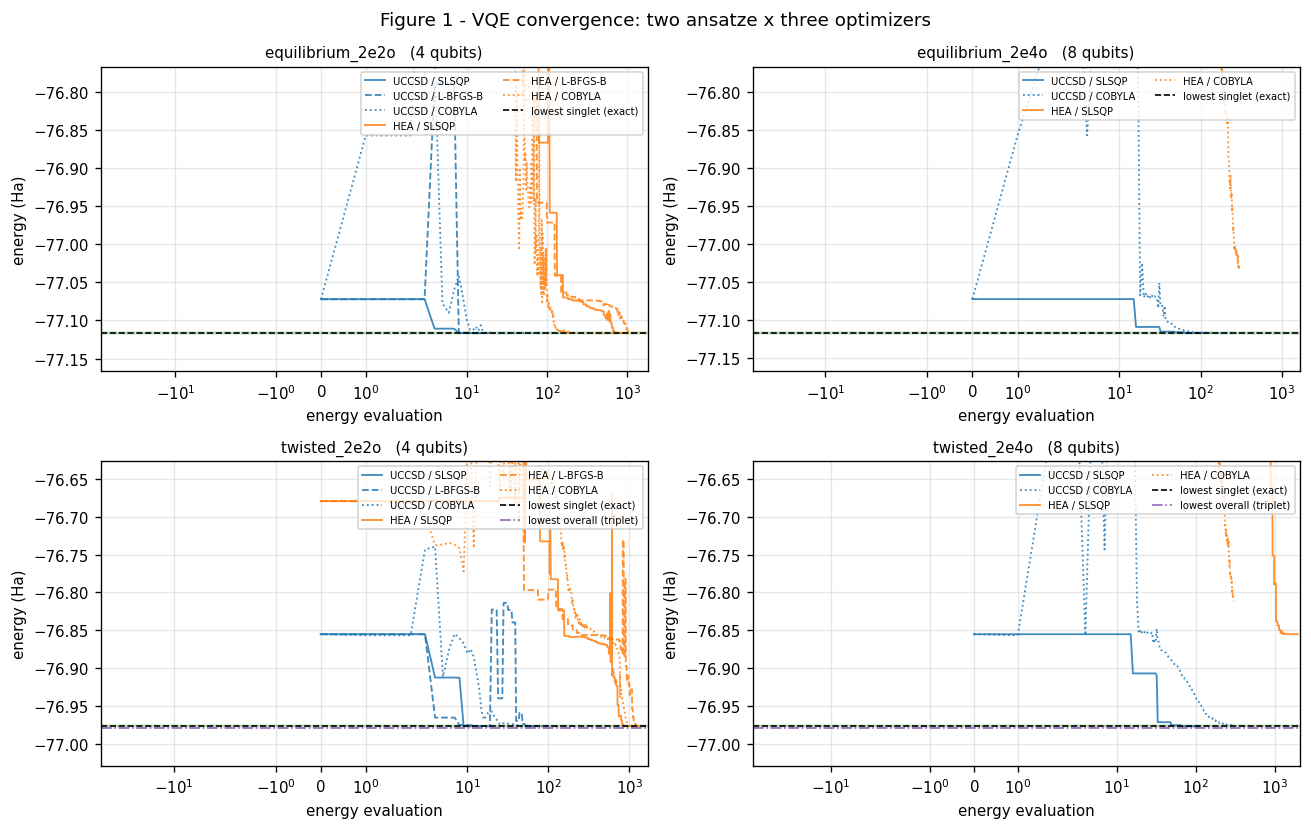

In [144]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=False)
for ax, key in zip(axes.ravel(), SYSTEMS):
    s = SYSTEMS[key]
    styles = {"SLSQP": "-", "L-BFGS-B": "--", "COBYLA": ":"}
    for aname, colour in [("UCCSD", "tab:blue"), ("HEA(EfficientSU2)", "tab:orange")]:
        for opt in OPTIMIZERS_BY_SIZE.get(s.n_orb, ["SLSQP", "COBYLA"]):
            r = VQE_RESULTS.get((key, aname, opt))
            if r is None:
                continue
            ax.plot(r["history"], styles.get(opt, "-"), color=colour, lw=1.1,
                    alpha=0.85, label=f"{aname.split('(')[0]} / {opt}")
    e_s0 = REFERENCE[key]["e_singlet"]
    ax.axhline(e_s0, color="k", ls="--", lw=1, label="lowest singlet (exact)")
    ax.axhspan(e_s0 - CHEMICAL_ACCURACY_HA, e_s0 + CHEMICAL_ACCURACY_HA,
               color="green", alpha=0.15)
    if REFERENCE[key]["spin_lowest"] != "singlet":
        ax.axhline(REFERENCE[key]["e_lowest"], color="tab:purple", ls="-.", lw=1,
                   label="lowest overall (triplet)")
    ax.set_title(f"{key}   ({s.n_qubits} qubits)", fontsize=9)
    ax.set_xlabel("energy evaluation"); ax.set_ylabel("energy (Ha)")
    ax.set_xscale("symlog")
    lo, hi = min(e_s0, REFERENCE[key]["e_lowest"]) - 0.05, e_s0 + 0.35
    ax.set_ylim(lo, hi)
    ax.legend(fontsize=6, ncol=2, loc="upper right")
fig.suptitle("Figure 1 - VQE convergence: two ansatze x three optimizers", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "fig1_vqe_convergence.png", bbox_inches="tight")
plt.show()

## 2.4 — Symmetry audit of the converged states

A hardware-efficient ansatz applies arbitrary single-qubit rotations and
entanglers, so it does **not** preserve particle number or total spin. A converged
energy that looks good can therefore belong to a state with the wrong number of
electrons — a variational energy below the true ground state of the target sector
is the tell-tale sign.

Every converged state is audited here for ⟨N⟩ and ⟨S²⟩. A physical singlet ground
state of these active spaces must give ⟨N⟩ = 2 and ⟨S²⟩ = 0.

In [145]:
N_TOL, S2_TOL = 1e-4, 1e-3

hdr = (f"{'system':<20}{'ansatz':<20}{'opt':<11}{'<N>':>10}{'<S2>':>10}"
       f"{'spin':>10}{'verdict':>24}")
print(hdr); print("-" * len(hdr))
sym_rows = []
for (key, aname, opt), r in VQE_RESULTS.items():
    s, ops = SYSTEMS[key], SYM_OPS[key]
    psi = np.asarray(Statevector(
        (make_uccsd(s) if aname == "UCCSD" else make_hea(s)
         ).assign_parameters(r["x"])).data)
    n_val = float(np.real(np.vdot(psi, ops["N"] @ psi)))
    s2_val = float(np.real(np.vdot(psi, ops["S2"] @ psi)))
    bad_n = abs(n_val - s.n_elec) > N_TOL
    bad_s = abs(s2_val) > S2_TOL
    if bad_n and bad_s:
        verdict = "WRONG N AND SPIN"
    elif bad_n:
        verdict = "WRONG PARTICLE NUMBER"
    elif bad_s:
        verdict = "SPIN CONTAMINATED"
    else:
        verdict = "OK"
    print(f"{key:<20}{aname:<20}{opt:<11}{n_val:>10.6f}{s2_val:>10.6f}"
          f"{spin_label(s2_val):>10}{verdict:>24}")
    sym_rows.append(dict(system=key, ansatz=aname, optimizer=opt,
                         n_expect=n_val, s2_expect=s2_val,
                         spin=spin_label(s2_val), verdict=verdict))
STORE["vqe_symmetry_audit"] = sym_rows

system              ansatz              opt               <N>      <S2>      spin                 verdict
---------------------------------------------------------------------------------------------------------
equilibrium_2e2o    UCCSD               SLSQP        2.000000  0.000000   singlet                      OK
equilibrium_2e2o    UCCSD               L-BFGS-B     2.000000  0.000000   singlet                      OK
equilibrium_2e2o    UCCSD               COBYLA       2.000000  0.000000   singlet                      OK
equilibrium_2e2o    HEA(EfficientSU2)   SLSQP        2.000000  0.000000   singlet                      OK
equilibrium_2e2o    HEA(EfficientSU2)   L-BFGS-B     2.000000  0.000000   singlet                      OK
equilibrium_2e2o    HEA(EfficientSU2)   COBYLA       2.000000  0.000000   singlet                      OK
equilibrium_2e4o    UCCSD               SLSQP        2.000000  0.000000   singlet                      OK
equilibrium_2e4o    UCCSD               COBYLA

In [146]:
hdr = (f"{'system':<18}{'ansatz':<20}{'penalty':<9}{'E (Ha)':>16}"
       f"{'err vs S0':>12}{'<S2>':>9}{'spin':>10}")
print(hdr); print("-" * len(hdr))
penalty_rows = []
for key in ("equilibrium_2e2o", "twisted_2e2o"):
    s = SYSTEMS[key]
    for aname, anz in (("UCCSD", make_uccsd(s)),
                       ("HEA(EfficientSU2)", make_hea(s))):
        x0 = (np.zeros(anz.num_parameters) if aname == "UCCSD"
              else np.random.default_rng(SEED).normal(0, 0.1, anz.num_parameters))
        for tag, on in (("off", False), ("on", True)):
            r = run_vqe_multistart(s, anz, "SLSQP", x0, n_restarts=2) if on else \
                min((run_vqe(s, anz, method="SLSQP", x0=x0, penalise=False),
                     *(run_vqe(s, anz, method="SLSQP", penalise=False,
                               x0=np.random.default_rng(SEED + 31 * t).normal(
                                   0, 0.25, anz.num_parameters))
                       for t in range(2))), key=lambda d: d["energy"])
            psi = np.asarray(Statevector(anz.assign_parameters(r["x"])).data)
            s2v = float(np.real(np.vdot(psi, SYM_OPS[key]["S2"] @ psi)))
            err = r["energy"] - REFERENCE[key]["e_singlet"]
            print(f"{key:<18}{aname:<20}{tag:<9}{r['energy']:>16.9f}"
                  f"{err:>12.2e}{s2v:>9.5f}{spin_label(s2v):>10}")
            penalty_rows.append(dict(system=key, ansatz=aname, penalty=tag,
                                     energy=r["energy"], err_vs_singlet=err,
                                     s2=s2v, spin=spin_label(s2v)))
STORE["penalty_comparison"] = penalty_rows

system            ansatz              penalty            E (Ha)   err vs S0     <S2>      spin
----------------------------------------------------------------------------------------------
equilibrium_2e2o  UCCSD               off         -77.116591876    1.22e-10  0.00000   singlet
equilibrium_2e2o  UCCSD               on          -77.116591876    1.22e-10  0.00000   singlet
equilibrium_2e2o  HEA(EfficientSU2)   off         -77.116588841    3.04e-06  0.00000   singlet
equilibrium_2e2o  HEA(EfficientSU2)   on          -77.116591831    4.60e-08  0.00000   singlet
twisted_2e2o      UCCSD               off         -76.978207747   -1.28e-03  1.00000mixed(1.00)
twisted_2e2o      UCCSD               on          -76.976928215    2.93e-11  0.00000   singlet
twisted_2e2o      HEA(EfficientSU2)   off         -76.979487198   -2.56e-03  1.99999   triplet
twisted_2e2o      HEA(EfficientSU2)   on          -76.976928185    3.00e-08  0.00000   singlet


## 2.5 — Circuit cost after transpilation

In [147]:
TWO_QUBIT_GATES = {"cx", "cz", "ecr", "cy", "swap", "iswap"}

def transpiled_cost(circuit, n_qubits, seed=SEED):
    basis = ["rz", "sx", "x", "cx"]
    coupling = [[i, i + 1] for i in range(n_qubits - 1)]
    tqc = transpile(circuit, basis_gates=basis, coupling_map=coupling,
                    optimization_level=3, seed_transpiler=seed)
    ops = dict(tqc.count_ops())
    return dict(depth=int(tqc.depth()), size=int(tqc.size()),
                two_qubit=int(sum(v for k, v in ops.items() if k in TWO_QUBIT_GATES)),
                ops=ops)


hdr = (f"{'system':<20}{'ansatz':<20}{'qubits':>7}{'params':>7}"
       f"{'depth':>8}{'2q gates':>10}{'total gates':>13}")
print(hdr); print("-" * len(hdr))
cost_rows = []
for key, s in SYSTEMS.items():
    for aname, ansatz in [("UCCSD", make_uccsd(s)), ("HEA(EfficientSU2)", make_hea(s))]:
        probe = ansatz.assign_parameters(
            np.random.default_rng(SEED).uniform(0.1, 0.9, ansatz.num_parameters))
        c = transpiled_cost(probe, s.n_qubits)
        print(f"{key:<20}{aname:<20}{s.n_qubits:>7}{ansatz.num_parameters:>7}"
              f"{c['depth']:>8}{c['two_qubit']:>10}{c['size']:>13}")
        cost_rows.append(dict(system=key, ansatz=aname, qubits=s.n_qubits,
                              n_params=int(ansatz.num_parameters), **
                              {k: v for k, v in c.items() if k != "ops"}))
STORE["circuit_costs"] = cost_rows

system              ansatz               qubits params   depth  2q gates  total gates
-------------------------------------------------------------------------------------
equilibrium_2e2o    UCCSD                     4      3     110        45          180
equilibrium_2e2o    HEA(EfficientSU2)         4     24      17         6           56
equilibrium_2e4o    UCCSD                     8     15    2721       708         4177
equilibrium_2e4o    HEA(EfficientSU2)         8     48      28        14          119
twisted_2e2o        UCCSD                     4      3     110        45          180
twisted_2e2o        HEA(EfficientSU2)         4     24      17         6           56
twisted_2e4o        UCCSD                     8     15    2721       708         4177
twisted_2e4o        HEA(EfficientSU2)         8     48      28        14          119


---
# 3 — Excited states via Quantum Subspace Expansion

QSE builds a small basis by acting on the converged VQE ground state |ψ₀⟩ with a
pool of excitation operators {Ôᵢ}, then solves the generalized eigenvalue problem

$$\mathbf{H}\,\mathbf{c} = E\,\mathbf{S}\,\mathbf{c}, \qquad
H_{ij} = \langle\psi_0|\hat O_i^\dagger \hat H \hat O_j|\psi_0\rangle, \qquad
S_{ij} = \langle\psi_0|\hat O_i^\dagger \hat O_j|\psi_0\rangle.$$

Three implementation points that decide whether this works at all:

1. **The identity is in the pool.** Without it the ground state is not
   representable in the subspace and every root is pushed up.
2. **S is deliberately rank-deficient.** The pool is larger than the reachable
   space, so S is singular by construction, not by accident. It must be handled by
   thresholded eigendecomposition and canonical orthogonalisation.
3. **QSE runs in the untapered Jordan–Wigner space.** The excitation operators
   break exactly the symmetries that Z₂ tapering factors out, so a tapered
   Hamiltonian cannot host this subspace.

In [148]:
def excitation_pool(system, include_doubles=False):
    n_orb = system.problem.num_spatial_orbitals
    n_so = 2 * n_orb
    spin = lambda p: p // n_orb

    ops = [SparsePauliOp("I" * system.n_qubits)]
    labels = ["I"]

    for p in range(n_so):
        for q in range(n_so):
            if p == q or spin(p) != spin(q):
                continue
            f = FermionicOp({f"+_{p} -_{q}": 1.0}, num_spin_orbitals=n_so)
            ops.append(system.mapper.map(f))
            labels.append(f"S {q}->{p}")

    if include_doubles:
        for (p, q) in itertools.combinations(range(n_so), 2):
            for (r, t) in itertools.combinations(range(n_so), 2):
                if spin(p) + spin(q) != spin(r) + spin(t):
                    continue
                f = FermionicOp({f"+_{p} +_{q} -_{r} -_{t}": 1.0},
                                num_spin_orbitals=n_so)
                ops.append(system.mapper.map(f))
                labels.append(f"D {r},{t}->{p},{q}")

    return ops, labels


def qse_subspace(system, psi, ops):
    cols = []
    for op in ops:
        cols.append(np.asarray(op.to_matrix(sparse=True) @ psi).ravel())
    V = np.column_stack(cols)
    S = V.conj().T @ V
    H = V.conj().T @ (system.H_matrix @ V)
    return H, S, V


def solve_qse(H, S, threshold=1e-8):
    S = 0.5 * (S + S.conj().T)
    H = 0.5 * (H + H.conj().T)
    w, U = np.linalg.eigh(S)
    keep = w > threshold
    if keep.sum() == 0:
        raise ValueError("overlap matrix has no eigenvalue above the threshold")
    X = U[:, keep] / np.sqrt(w[keep])           # X^dag S X = I
    Hp = X.conj().T @ H @ X
    Hp = 0.5 * (Hp + Hp.conj().T)
    e, C = np.linalg.eigh(Hp)
    return np.real(e), X @ C, dict(n_kept=int(keep.sum()), n_total=int(len(w)),
                                   s_eigenvalues=np.sort(w)[::-1])

## 3.2 — Exact reference spectrum

In [149]:
def _find_property(props, type_name):
    for attr in dir(props):
        if attr.startswith("_"):
            continue
        try:
            obj = getattr(props, attr)
        except Exception:
            continue
        if obj is not None and type(obj).__name__ == type_name:
            return obj
    return None


_DIPOLE_CACHE = {}

def dipole_operators(system):
    if system.key in _DIPOLE_CACHE:
        return _DIPOLE_CACHE[system.key]
    out = {}
    dip = _find_property(system.problem.properties, "ElectronicDipoleMoment")
    if dip is None:
        print(f"  [{system.key}] no ElectronicDipoleMoment on the problem: "
              "oscillator strengths unavailable, states labelled by spin only")
    else:
        try:
            for name, op in dip.second_q_ops().items():
                out[name] = np.asarray(system.mapper.map(op).to_matrix())
        except Exception as exc:
            print(f"  [{system.key}] dipole operators unavailable: "
                  f"{type(exc).__name__}: {exc}")
            out = {}
    _DIPOLE_CACHE[system.key] = out
    return out


def label_roots(system, V, energies, vectors, sym_ops, dip_ops, n_report=6,
                ref_s2=0.0, s2_tol=0.2):
    N_sub = V.conj().T @ sym_ops["N"] @ V
    S2_sub = V.conj().T @ sym_ops["S2"] @ V
    dip_sub = {k: V.conj().T @ m @ V for k, m in dip_ops.items()}

    n_show = min(n_report, vectors.shape[1])
    s2_all = [float(np.real(vectors[:, k].conj() @ S2_sub @ vectors[:, k]))
              for k in range(n_show)]

    ref = next((k for k in range(n_show) if abs(s2_all[k] - ref_s2) < s2_tol), 0)
    c_ref, e_ref = vectors[:, ref], energies[ref]

    rows = []
    for k in range(n_show):
        ck = vectors[:, k]
        mu2 = sum(abs(complex(c_ref.conj() @ m @ ck)) ** 2 for m in dip_sub.values())
        de = float(energies[k] - e_ref)
        rows.append(dict(
            root=k,
            energy=float(energies[k]),
            dE_eV=de * HARTREE_TO_EV,
            n_expect=float(np.real(ck.conj() @ N_sub @ ck)),
            s2_expect=s2_all[k],
            osc_strength=float(2.0 / 3.0 * de * mu2) if de > 0 else 0.0,
            is_reference=(k == ref),
            reference_root=ref,
        ))
    return rows

## 3.3 — Running QSE: singles vs. singles + doubles, at both geometries

The ground state fed into QSE is the converged UCCSD/SLSQP state from Section 2.

In [150]:
def best_singlet_state(key, n_tol=1e-3, s2_tol=1e-2, ansatz_filter=None):
    s = SYSTEMS[key]
    ops = SYM_OPS[key]
    best = None
    for (k, aname, opt), r in VQE_RESULTS.items():
        if k != key or (ansatz_filter and aname != ansatz_filter):
            continue
        anz = make_uccsd(s) if aname == "UCCSD" else make_hea(s)
        psi = np.asarray(Statevector(anz.assign_parameters(r["x"])).data)
        n_val = float(np.real(np.vdot(psi, ops["N"] @ psi)))
        s2_val = float(np.real(np.vdot(psi, ops["S2"] @ psi)))
        if abs(n_val - s.n_elec) > n_tol or abs(s2_val) > s2_tol:
            continue
        if best is None or r["energy"] < best["energy"]:
            best = dict(energy=r["energy"], psi=psi, ansatz=aname, optimizer=opt,
                        s2=s2_val, n=n_val,
                        circuit=anz.assign_parameters(r["x"]))
    if best is None:
        r = VQE_RESULTS[(key, "UCCSD", "SLSQP")]
        psi = np.asarray(Statevector(make_uccsd(s).assign_parameters(r["x"])).data)
        print(f"  [{key}] WARNING: no run landed in the singlet sector; "
              "falling back to UCCSD/SLSQP")
        best = dict(energy=r["energy"], psi=psi, ansatz="UCCSD",
                    optimizer="SLSQP", s2=float("nan"), n=float("nan"),
                    circuit=make_uccsd(s).assign_parameters(r["x"]))
    return best


QSE_RESULTS = {}
QSE_REFERENCE = {}

print("Reference state chosen for QSE (lowest converged singlet):")
for key in SYSTEMS:
    ref = best_singlet_state(key)
    QSE_REFERENCE[key] = ref
    print(f"  {key:<20} {ref['ansatz']:<20}{ref['optimizer']:<10}"
          f"E={ref['energy']:.8f}  err vs S0 "
          f"{ref['energy'] - REFERENCE[key]['e_singlet']:+.2e}  <S2>={ref['s2']:.2e}")
print()

for key, s in SYSTEMS.items():
    sym_ops = SYM_OPS[key]
    dip_ops = dipole_operators(s)
    psi = QSE_REFERENCE[key]["psi"]
    r = dict(energy=QSE_REFERENCE[key]["energy"])

    for pool_name, doubles in [("singles", False), ("singles+doubles", True)]:
        ops, labels = excitation_pool(s, include_doubles=doubles)
        H, S, V = qse_subspace(s, psi, ops)
        energies, vectors, info = solve_qse(H, S, threshold=1e-8)
        energies = energies + s.shift
        rows = label_roots(s, V, energies, vectors, sym_ops, dip_ops)
        QSE_RESULTS[(key, pool_name)] = dict(
            rows=rows, info=info, n_ops=len(ops), energies=energies,
            H=H, S=S, V=V, vectors=vectors, psi=psi)
        print(f"{key:<20} {pool_name:<16} ops={len(ops):>4}  "
              f"subspace kept {info['n_kept']:>3}/{info['n_total']:<4} "
              f"E0={energies[0]:.8f} Ha  (VQE {r['energy']:.8f})")

Reference state chosen for QSE (lowest converged singlet):
  equilibrium_2e2o     UCCSD               COBYLA    E=-77.11659188  err vs S0 +0.00e+00  <S2>=6.89e-16
  equilibrium_2e4o     UCCSD               SLSQP     E=-77.11677747  err vs S0 +1.24e-08  <S2>=0.00e+00
  twisted_2e2o         UCCSD               COBYLA    E=-76.97692821  err vs S0 +2.84e-14  <S2>=2.78e-16
  twisted_2e4o         UCCSD               SLSQP     E=-76.97692822  err vs S0 +1.45e-11  <S2>=6.89e-41

equilibrium_2e2o     singles          ops=   5  subspace kept   3/5    E0=-77.11659188 Ha  (VQE -77.11659188)
equilibrium_2e2o     singles+doubles  ops=  23  subspace kept   4/23   E0=-77.11659188 Ha  (VQE -77.11659188)
equilibrium_2e4o     singles          ops=  25  subspace kept  13/25   E0=-77.11677747 Ha  (VQE -77.11677747)
equilibrium_2e4o     singles+doubles  ops= 353  subspace kept  16/353  E0=-77.11677748 Ha  (VQE -77.11677747)
twisted_2e2o         singles          ops=   5  subspace kept   3/5    E0=-76.979487

In [151]:
for key in SYSTEMS:
    e_ex, s2_ex = EXACT_SPECTRA[key]
    ex_ref = exact_reference_root(s2_ex)
    print("=" * 96)
    print(f"{key}")
    print("=" * 96)
    for pool_name in ["singles", "singles+doubles"]:
        res = QSE_RESULTS[(key, pool_name)]
        print(f"\n  pool = {pool_name}   ({res['n_ops']} operators, "
              f"{res['info']['n_kept']} retained)")
        print(f"  {'root':>4}{'E (Ha)':>16}{'dE (eV)':>10}{'<N>':>8}{'<S2>':>8}"
              f"{'spin':>10}{'f_osc':>10}   | {'exact dE (eV)':>14}{'exact spin':>12}")
        for row in res["rows"]:
            k = row["root"]
            if k < len(e_ex):
                ex_de = (e_ex[k] - e_ex[ex_ref]) * HARTREE_TO_EV
                ex_sp = spin_label(s2_ex[k])
            else:
                ex_de, ex_sp = float("nan"), "-"
            print(f"  {k:>4}{row['energy']:>16.8f}{row['dE_eV']:>10.3f}"
                  f"{row['n_expect']:>8.4f}{row['s2_expect']:>8.4f}"
                  f"{spin_label(row['s2_expect']):>10}{row['osc_strength']:>10.4f}"
                  f"   | {ex_de:>14.3f}{ex_sp:>12}")
    print()

STORE["qse_roots"] = {f"{k}|{p}": v["rows"] for (k, p), v in QSE_RESULTS.items()}

equilibrium_2e2o

  pool = singles   (5 operators, 3 retained)
  root          E (Ha)   dE (eV)     <N>    <S2>      spin     f_osc   |  exact dE (eV)  exact spin
     0    -77.11659188     0.000  2.0000  0.0000   singlet    0.0000   |          0.000     singlet
     1    -76.94049449     4.792  2.0000  2.0000   triplet    0.0000   |          4.792     triplet
     2    -76.59642172    14.155  2.0000  0.0000   singlet    0.6060   |         14.155     singlet

  pool = singles+doubles   (23 operators, 4 retained)
  root          E (Ha)   dE (eV)     <N>    <S2>      spin     f_osc   |  exact dE (eV)  exact spin
     0    -77.11659188     0.000  2.0000  0.0000   singlet    0.0000   |          0.000     singlet
     1    -76.94049449     4.792  2.0000  2.0000   triplet    0.0000   |          4.792     triplet
     2    -76.59642172    14.155  2.0000  0.0000   singlet    0.6060   |         14.155     singlet
     3    -76.40707202    19.307  2.0000 -0.0000   singlet    0.0000   |         1

## 3.4 — The π→π\* vertical excitation energy

In [152]:
DIPOLES_AVAILABLE = any(bool(dipole_operators(s)) for s in SYSTEMS.values())
if not DIPOLES_AVAILABLE:
    print("\nNOTE: oscillator strengths are unavailable in this run, so the "
          "pi->pi* state\nis selected as the lowest SINGLET above the ground "
          "state rather than the\nlowest BRIGHT singlet. If a dark singlet lies "
          "below the ππ* state, this will\npick the wrong root - check the <S2> "
          "and dE columns in the tables above.")


def pi_pistar(rows, require_bright=None, f_min=1e-6):
    if require_bright is None:
        require_bright = DIPOLES_AVAILABLE
    ref = rows[0].get("reference_root", 0)
    # Candidates lie ABOVE the same-multiplicity reference root, not above root 0.
    singlets = [r for r in rows
                if r["root"] > ref and abs(r["s2_expect"]) < 0.2]
    if not singlets:
        return None
    if require_bright:
        bright = [r for r in singlets if r["osc_strength"] >= f_min]
        if bright:
            return dict(bright[0], selection="bright singlet")
    return dict(singlets[0], selection="lowest singlet (all dark)")


hdr = (f"{'system':<20}{'pool':<17}{'root':>5}{'dE (eV)':>10}{'f_osc':>9}"
       f"{'exact (eV)':>12}{'err vs exact':>14}{'vs 7.66 eV':>12}")
print(hdr); print("-" * len(hdr))
pipi_rows = []
for key in SYSTEMS:
    e_ex, s2_ex = EXACT_SPECTRA[key]
    ex_ref = exact_reference_root(s2_ex)
    bright_exact = [i for i in range(ex_ref + 1, len(e_ex)) if abs(s2_ex[i]) < 0.2]
    ex_de = ((e_ex[bright_exact[0]] - e_ex[ex_ref]) * HARTREE_TO_EV
             if bright_exact else float("nan"))
    for pool_name in ["singles", "singles+doubles"]:
        row = pi_pistar(QSE_RESULTS[(key, pool_name)]["rows"])
        if row is None:
            print(f"{key:<20}{pool_name:<17}{'-':>5}{'none found':>10}")
            pipi_rows.append(dict(system=key, pool=pool_name, found=False))
            continue
        flag = "" if row.get("selection", "").startswith("bright") else "  (dark)"
        print(f"{key:<20}{pool_name:<17}{row['root']:>5}{row['dE_eV']:>10.3f}"
              f"{row['osc_strength']:>9.4f}{ex_de:>12.3f}"
              f"{row['dE_eV'] - ex_de:>14.3f}"
              f"{row['dE_eV'] - EXPT_PI_PISTAR_EV:>12.3f}{flag}")
        pipi_rows.append(dict(system=key, pool=pool_name, found=True,
                              root=row["root"], dE_eV=row["dE_eV"],
                              selection=row.get("selection", "bright singlet"),
                              osc=row["osc_strength"], exact_eV=float(ex_de),
                              err_vs_exact_eV=row["dE_eV"] - ex_de,
                              err_vs_expt_eV=row["dE_eV"] - EXPT_PI_PISTAR_EV))
STORE["pi_pistar"] = pipi_rows

system              pool              root   dE (eV)    f_osc  exact (eV)  err vs exact  vs 7.66 eV
---------------------------------------------------------------------------------------------------
equilibrium_2e2o    singles              2    14.155   0.6060      14.155         0.000       6.495
equilibrium_2e2o    singles+doubles      2    14.155   0.6060      14.155         0.000       6.495
equilibrium_2e4o    singles              2    14.160   0.6070      14.160        -0.000       6.500
equilibrium_2e4o    singles+doubles      2    14.160   0.6073      14.160         0.000       6.500
twisted_2e2o        singles              2     6.580   0.0000       6.580         0.000      -1.080
twisted_2e2o        singles+doubles      2     6.580   0.0000       6.580         0.000      -1.080
twisted_2e4o        singles              2     6.580   0.0000       6.524         0.057      -1.080
twisted_2e4o        singles+doubles      3     6.557   0.0000       6.524         0.033      -1.103


## 3.5 — Conditioning of the overlap matrix

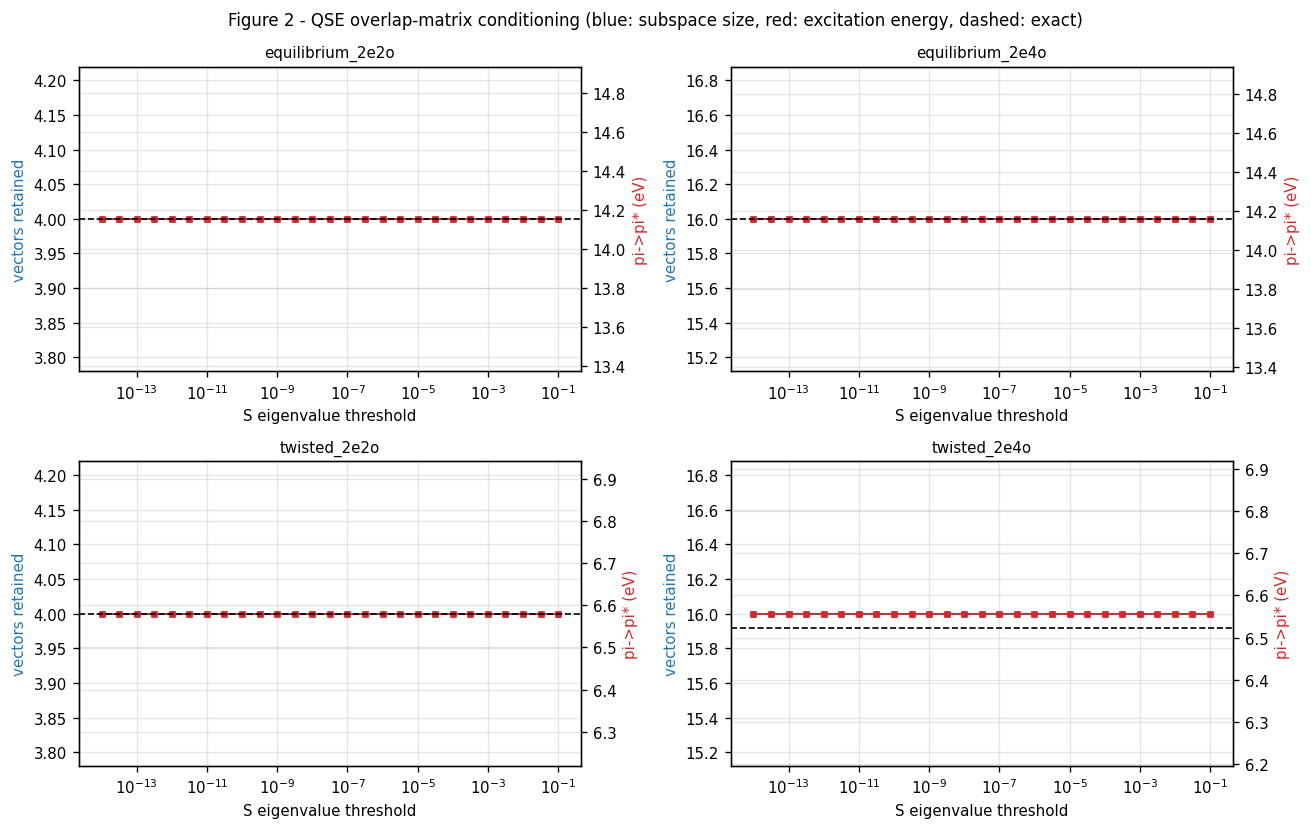

In [153]:
THRESHOLDS = np.logspace(-14, -1, 27)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
sweep_store = {}

for ax, key in zip(axes.ravel(), SYSTEMS):
    res = QSE_RESULTS[(key, "singles+doubles")]
    e_ex, s2_ex = EXACT_SPECTRA[key]
    ex_ref = exact_reference_root(s2_ex)
    bright = [i for i in range(ex_ref + 1, len(e_ex)) if abs(s2_ex[i]) < 0.2]
    ref_de = ((e_ex[bright[0]] - e_ex[ex_ref]) * HARTREE_TO_EV
              if bright else np.nan)

    kept, de_vals = [], []
    for th in THRESHOLDS:
        try:
            en, vecs, info = solve_qse(res["H"], res["S"], threshold=th)
            en = en + SYSTEMS[key].shift
            rows = label_roots(SYSTEMS[key], res["V"], en, vecs,
                               SYM_OPS[key], dipole_operators(SYSTEMS[key]))
            r = pi_pistar(rows)
            kept.append(info["n_kept"])
            de_vals.append(r["dE_eV"] if r else np.nan)
        except Exception:
            kept.append(0); de_vals.append(np.nan)

    ax2 = ax.twinx()
    ax.semilogx(THRESHOLDS, kept, "o-", color="tab:blue", ms=3, lw=1)
    ax2.semilogx(THRESHOLDS, de_vals, "s-", color="tab:red", ms=3, lw=1)
    if np.isfinite(ref_de):
        ax2.axhline(ref_de, color="k", ls="--", lw=1)
    ax.set_xlabel("S eigenvalue threshold")
    ax.set_ylabel("vectors retained", color="tab:blue")
    ax2.set_ylabel("pi->pi* (eV)", color="tab:red")
    ax.set_title(key, fontsize=9)
    sweep_store[key] = dict(thresholds=THRESHOLDS.tolist(), kept=kept,
                            dE_eV=[float(v) for v in de_vals],
                            reference_eV=float(ref_de))

fig.suptitle("Figure 2 - QSE overlap-matrix conditioning "
             "(blue: subspace size, red: excitation energy, dashed: exact)", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "fig2_qse_conditioning.png", bbox_inches="tight")
plt.show()
STORE["qse_threshold_sweep"] = sweep_store

## 3.6 — Level diagram

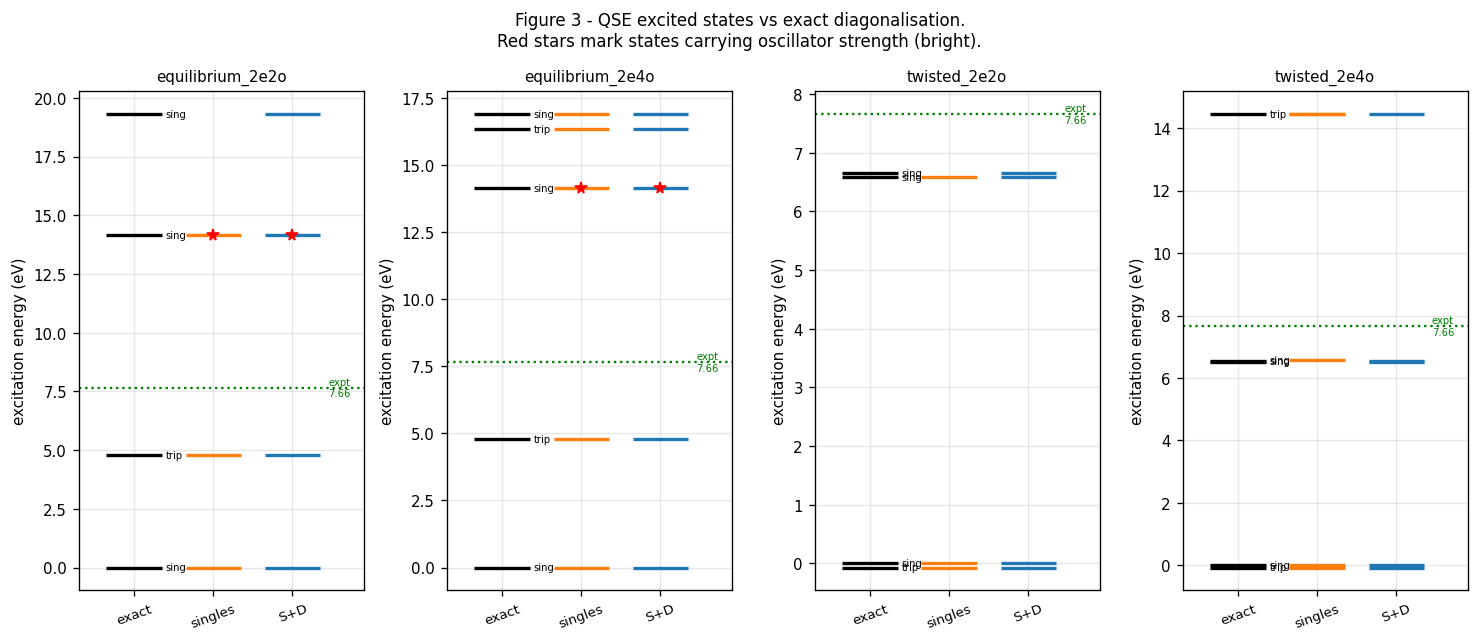

In [154]:
fig, axes = plt.subplots(1, len(SYSTEMS), figsize=(3.1 * len(SYSTEMS), 5.4), sharey=False)
axes = np.atleast_1d(axes)

for ax, key in zip(axes, SYSTEMS):
    e_ex, s2_ex = EXACT_SPECTRA[key]
    cols = {"exact": 0, "singles": 1, "singles+doubles": 2}
    n_show = 5

    for i in range(min(n_show, len(e_ex))):
        de = (e_ex[i] - e_ex[exact_reference_root(s2_ex)]) * HARTREE_TO_EV
        ax.hlines(de, -0.35, 0.35, color="k", lw=2)
        ax.text(0.40, de, spin_label(s2_ex[i])[:4], fontsize=6, va="center")

    for pool_name, xc in [("singles", 1), ("singles+doubles", 2)]:
        rows = QSE_RESULTS[(key, pool_name)]["rows"]
        colour = "tab:orange" if pool_name == "singles" else "tab:blue"
        for row in rows[:n_show]:
            ax.hlines(row["dE_eV"], xc - 0.35, xc + 0.35, color=colour, lw=2)
            if row["osc_strength"] > 1e-4:
                ax.plot(xc, row["dE_eV"], "*", color="red", ms=7)

    ax.axhline(EXPT_PI_PISTAR_EV, color="green", ls=":", lw=1.4)
    ax.text(2.45, EXPT_PI_PISTAR_EV, "expt\n7.66", fontsize=6, color="green", va="center")
    ax.set_xticks(list(cols.values()))
    ax.set_xticklabels(["exact", "singles", "S+D"], rotation=20, fontsize=8)
    ax.set_xlim(-0.7, 2.9)
    ax.set_ylabel("excitation energy (eV)")
    ax.set_title(key, fontsize=9)

fig.suptitle("Figure 3 - QSE excited states vs exact diagonalisation.\n"
             "Red stars mark states carrying oscillator strength (bright).", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "fig3_qse_levels.png", bbox_inches="tight")
plt.show()

In [155]:
print("Subspace truncation error in the pi->pi* energy (QSE minus exact, eV):\n")
hdr = f"{'system':<20}{'singles':>12}{'singles+doubles':>18}{'improvement':>14}"
print(hdr); print("-" * len(hdr))
for key in SYSTEMS:
    errs = {}
    for pool_name in ["singles", "singles+doubles"]:
        row = next((r for r in STORE["pi_pistar"]
                    if r["system"] == key and r["pool"] == pool_name), None)
        errs[pool_name] = row["err_vs_exact_eV"] if row and row.get("found") else np.nan
    imp = abs(errs["singles"]) - abs(errs["singles+doubles"])
    print(f"{key:<20}{errs['singles']:>12.3f}{errs['singles+doubles']:>18.3f}{imp:>14.3f}")

print("\nWhy these columns are all zero, and why that is the correct outcome:\n")
hdr = (f"{'system':<20}{'sector dim':>11}{'singles pool':>14}"
       f"{'kept (S)':>10}{'kept (S+D)':>12}   spans the sector?")
print(hdr); print("-" * (len(hdr) + 4))
span_rows = []
for key, s in SYSTEMS.items():
    dim = s.problem.num_spatial_orbitals ** 2      # (N=2, Sz=0): 1 alpha x 1 beta
    n_singles = QSE_RESULTS[(key, "singles")]["n_ops"]
    kept_s = QSE_RESULTS[(key, "singles")]["info"]["n_kept"]
    kept_sd = QSE_RESULTS[(key, "singles+doubles")]["info"]["n_kept"]
    spans = kept_s >= dim
    print(f"{key:<20}{dim:>11}{n_singles:>14}{kept_s:>10}{kept_sd:>12}"
          f"   {'YES' if spans else 'no'}")
    span_rows.append(dict(system=key, sector_dim=int(dim), singles_ops=int(n_singles),
                          kept_singles=int(kept_s), kept_sd=int(kept_sd),
                          singles_spans_sector=bool(spans)))
STORE["qse_span_analysis"] = span_rows

Subspace truncation error in the pi->pi* energy (QSE minus exact, eV):

system                   singles   singles+doubles   improvement
----------------------------------------------------------------
equilibrium_2e2o           0.000             0.000         0.000
equilibrium_2e4o          -0.000             0.000         0.000
twisted_2e2o               0.000             0.000         0.000
twisted_2e4o               0.057             0.033         0.024

Why these columns are all zero, and why that is the correct outcome:

system               sector dim  singles pool  kept (S)  kept (S+D)   spans the sector?
-------------------------------------------------------------------------------------------
equilibrium_2e2o              4             5         3           4   no
equilibrium_2e4o             16            25        13          16   no
twisted_2e2o                  4             5         3           4   no
twisted_2e4o                 16            25        11          16 

---
# 4 — Noise-aware benchmarking

In [156]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

FAKE_BACKEND = FakeManilaV2()
NOISY_SIM = AerSimulator.from_backend(FAKE_BACKEND)
IDEAL_SIM = AerSimulator()

print("noise model from:", FAKE_BACKEND.name, "|", FAKE_BACKEND.num_qubits, "qubits")
print("basis gates      :", list(FAKE_BACKEND.operation_names))
print("coupling map     :", FAKE_BACKEND.coupling_map)

DEVICE_BASIS = ["id", "rz", "sx", "x", "cx"]

def device_transpile(circ, optimization_level=3, seed=SEED):
    n = circ.num_qubits
    coupling = [[a, b] for a, b in FAKE_BACKEND.coupling_map if a < n and b < n]
    return transpile(circ, basis_gates=DEVICE_BASIS,
                     coupling_map=coupling or None,
                     optimization_level=optimization_level, seed_transpiler=seed)

NOISE_SYSTEMS = ["equilibrium_2e2o", "twisted_2e2o"]

noise model from: fake_manila | 5 qubits
basis gates      : ['id', 'measure', 'for_loop', 'switch_case', 'x', 'if_else', 'reset', 'sx', 'cx', 'delay', 'rz']
coupling map     : [[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3]]


### 4.1b — Two encodings of the same physics

The dominant error on a NISQ device is set by circuit depth, not by the molecule.
The same 2e/2o problem can be prepared two ways, and the difference is the whole
story of this section:

| encoding | qubits | ansatz | transpiled depth |
|---|---|---|---|
| Jordan–Wigner | 4 | UCCSD | ~110, 45 CX |
| **Z₂-tapered** | **1–2** | small real-amplitude | **a few gates** |

In [157]:
def tapered_problem(system):
    tmapper = system.problem.get_tapered_mapper(JordanWignerMapper())
    H_tap = tmapper.map(system.problem.hamiltonian.second_q_op())
    M = np.asarray(H_tap.to_matrix())
    return dict(mapper=tmapper, H=H_tap, M=M, n_qubits=H_tap.num_qubits,
                e_tapered_min=float(np.linalg.eigvalsh(M)[0].real) + system.shift)


def make_small_ansatz(n_qubits, reps):
    try:
        from qiskit.circuit.library import real_amplitudes
        return real_amplitudes(n_qubits, reps=reps, entanglement="linear")
    except ImportError:
        from qiskit.circuit.library import RealAmplitudes
        return RealAmplitudes(n_qubits, reps=reps, entanglement="linear")


def prepare_tapered(system):
    tp = tapered_problem(system)
    gap = abs(tp["e_tapered_min"] - system.e_exact)
    assert gap < 1e-8, (f"{system.key}: tapered sector does not contain the ground "
                        f"state (off by {gap:.2e} Ha)")
    best = None
    for reps in (1, 2, 3, 4):
        anz = make_small_ansatz(tp["n_qubits"], reps)
        cand = min(
            (minimize(lambda x: float(np.real(np.vdot(
                 (p := np.asarray(Statevector(anz.assign_parameters(x)).data)),
                 tp["M"] @ p))) + system.shift,
                 np.random.default_rng(SEED + 17 * t).normal(0, 0.5,
                                                             anz.num_parameters),
                 method="SLSQP", options={"maxiter": 800})
             for t in range(4)), key=lambda r: r.fun)
        if best is None or cand.fun < best["energy"]:
            best = dict(reps=reps, ansatz=anz, x=np.asarray(cand.x),
                        energy=float(cand.fun),
                        error=float(cand.fun - system.e_exact))
        if abs(cand.fun - system.e_exact) < 1e-8:
            break
    assert abs(best["error"]) < 1e-6, (
        f"{system.key}: small ansatz cannot reach the tapered ground state "
        f"(error {best['error']:.2e} Ha)")
    return dict(system=system, **tp, **best)


NOISE_PREP = {}
hdr = (f"{'system':<20}{'JW q':>6}{'tapered q':>11}{'reps':>6}{'params':>8}"
       f"{'noiseless err':>15}{'depth (JW)':>12}{'depth (tap)':>13}")
print(hdr); print("-" * len(hdr))
for key in NOISE_SYSTEMS:
    s = SYSTEMS[key]
    prep = prepare_tapered(s)
    NOISE_PREP[key] = prep
    d_jw = device_transpile(make_uccsd(s).assign_parameters(
        VQE_RESULTS[(key, "UCCSD", "SLSQP")]["x"])).depth()
    d_tap = device_transpile(prep["ansatz"].assign_parameters(prep["x"])).depth()
    print(f"{key:<20}{s.n_qubits:>6}{prep['n_qubits']:>11}{prep['reps']:>6}"
          f"{prep['ansatz'].num_parameters:>8}{prep['error']:>15.2e}"
          f"{d_jw:>12}{d_tap:>13}")
STORE["noise_encodings"] = [
    dict(system=k, jw_qubits=SYSTEMS[k].n_qubits, tapered_qubits=v["n_qubits"],
         reps=v["reps"], noiseless_error_ha=v["error"]) for k, v in NOISE_PREP.items()]

system                JW q  tapered q  reps  params  noiseless err  depth (JW)  depth (tap)
-------------------------------------------------------------------------------------------
equilibrium_2e2o         4          1     1       2       6.26e-11          88            4
twisted_2e2o             4          2     4      10       3.64e-08          91           13


In [158]:
def _split_phase(label):
    ph, i = 1 + 0j, 0
    while i < len(label) and label[i] in "+-i":
        if label[i] == "-":
            ph *= -1
        elif label[i] == "i":
            ph *= 1j
        i += 1
    return ph, label[i:]


def group_basis(group, n_qubits):
    basis = ["I"] * n_qubits
    for raw in group.paulis.to_labels():
        _, lab = _split_phase(raw)
        for q, ch in enumerate(lab[::-1]):
            if ch != "I":
                basis[q] = ch
    return basis


def measurement_circuit(state_circ, basis):
    qc = state_circ.copy()
    for q, b in enumerate(basis):
        if b == "X":
            qc.h(q)
        elif b == "Y":
            qc.sdg(q); qc.h(q)
    qc.measure_all()
    return qc


def counts_to_probs(counts, n_qubits, shots):
    p = np.zeros(2 ** n_qubits)
    for bits, c in counts.items():
        p[int(bits.replace(" ", ""), 2)] += c / shots
    return p


def pauli_expval_from_probs(probs, label, n_qubits):
    qubits = [q for q, ch in enumerate(label[::-1]) if ch != "I"]
    if not qubits:
        return 1.0
    val = 0.0
    for idx, p in enumerate(probs):
        if p == 0.0:
            continue
        parity = sum((idx >> q) & 1 for q in qubits) & 1
        val += -p if parity else p
    return float(val)

## 4.2 — Readout mitigation

In [159]:
def readout_calibration(n_qubits, shots=8192, seed=SEED):
    M = np.zeros((2 ** n_qubits, 2 ** n_qubits))
    for i in range(2 ** n_qubits):
        qc = QuantumCircuit(n_qubits)
        for q in range(n_qubits):
            if (i >> q) & 1:
                qc.x(q)
        qc.measure_all()
        tqc = device_transpile(qc, optimization_level=1, seed=seed)
        counts = NOISY_SIM.run(tqc, shots=shots, seed_simulator=seed).result().get_counts()
        M[:, i] = counts_to_probs(counts, n_qubits, shots)
    return M


def mitigate_probs(p, M):
    corrected, *_ = np.linalg.lstsq(M, p, rcond=None)
    corrected = np.clip(corrected, 0.0, None)
    total = corrected.sum()
    return corrected / total if total > 0 else p

_ASSIGNMENT_CACHE = {}

def assignment_for(n_qubits):
    if n_qubits not in _ASSIGNMENT_CACHE:
        t0 = time.time()
        _ASSIGNMENT_CACHE[n_qubits] = readout_calibration(n_qubits)
        print(f"  calibrated {2**n_qubits}x{2**n_qubits} assignment matrix "
              f"({n_qubits} qubits) in {time.time()-t0:.1f} s")
    return _ASSIGNMENT_CACHE[n_qubits]


widths = sorted({SYSTEMS[k].n_qubits for k in NOISE_SYSTEMS} |
                {NOISE_PREP[k]["n_qubits"] for k in NOISE_SYSTEMS})
for w in widths:
    M = assignment_for(w)
    print(f"  {w} qubits: mean diagonal {np.mean(np.diag(M)):.4f}, "
          f"worst {np.min(np.diag(M)):.4f}")

N_NOISE_QUBITS = SYSTEMS[NOISE_SYSTEMS[0]].n_qubits
ASSIGNMENT_M = assignment_for(N_NOISE_QUBITS)

  calibrated 2x2 assignment matrix (1 qubits) in 0.2 s
  1 qubits: mean diagonal 0.9645, worst 0.9639
  calibrated 4x4 assignment matrix (2 qubits) in 0.4 s
  2 qubits: mean diagonal 0.9433, worst 0.9420
  calibrated 16x16 assignment matrix (4 qubits) in 1.7 s
  4 qubits: mean diagonal 0.8431, worst 0.8387


## 4.3 — Zero-noise extrapolation

Noise is amplified by **global unitary folding**: the circuit U is replaced by
U (U†U)ⁿ, which is logically the identity-extended same operation but exposes the
hardware to a scale factor λ = 2n+1 more noise. Energies are then fitted against λ
and extrapolated to λ = 0.

Barriers are inserted between folds so the transpiler cannot cancel U†U back to U.

In [160]:
def fold_global(circuit, scale):
    if scale == 1:
        return circuit.copy()
    assert scale % 2 == 1, "global folding supports odd scale factors"
    folded = circuit.copy()
    inv = circuit.inverse()
    for _ in range((scale - 1) // 2):
        folded.barrier()
        folded = folded.compose(inv)
        folded.barrier()
        folded = folded.compose(circuit)
    return folded


def extrapolate(scales, values):
    scales = np.asarray(scales, float); values = np.asarray(values, float)
    lin = float(np.polyval(np.polyfit(scales, values, 1), 0.0))
    exp = np.nan
    try:
        asym = values[-1]
        shifted = values - asym
        if np.all(np.abs(shifted[:-1]) > 1e-12) and np.all(np.sign(shifted[:-1]) == np.sign(shifted[0])):
            sgn = np.sign(shifted[0])
            coef = np.polyfit(scales[:-1], np.log(np.abs(shifted[:-1])), 1)
            exp = float(asym + sgn * np.exp(np.polyval(coef, 0.0)))
    except Exception:
        pass
    return lin, exp

## 4.4 — Measuring a set of Pauli operators

In [161]:
def measure_pauli_set(state_circ, pauli_labels, shots=8192, seed=SEED,
                      noisy=True, fold=1, mitigate=False, assignment=None):
    n = state_circ.num_qubits
    labels = sorted(set(pauli_labels))
    non_identity = [l for l in labels if set(l) != {"I"}]
    values = {l: 1.0 for l in labels if set(l) == {"I"}}
    if not non_identity:
        return values, 0

    bundle = SparsePauliOp(non_identity, coeffs=np.ones(len(non_identity)))
    groups = bundle.group_commuting(qubit_wise=True)

    sim = NOISY_SIM if noisy else IDEAL_SIM
    folded = fold_global(state_circ, fold)

    circuits, metas = [], []
    for g in groups:
        basis = group_basis(g, n)
        circuits.append(measurement_circuit(folded, basis))
        metas.append(g)

    tqcs = [device_transpile(c, optimization_level=1, seed=seed) for c in circuits]
    result = sim.run(tqcs, shots=shots, seed_simulator=seed).result()

    for i, g in enumerate(metas):
        probs = counts_to_probs(result.get_counts(i), n, shots)
        if mitigate and assignment is not None:
            probs = mitigate_probs(probs, assignment)
        for raw in g.paulis.to_labels():
            ph, lab = _split_phase(raw)
            values[lab] = pauli_expval_from_probs(probs, lab, n)
    return values, len(circuits)


def observable_from_values(spo, values):
    total = 0.0 + 0.0j
    for raw, coeff in zip(spo.paulis.to_labels(), spo.coeffs):
        ph, lab = _split_phase(raw)
        total += complex(coeff) * ph * values.get(lab, 0.0)
    return float(total.real)

## 4.5 — Ground-state energy under noise

Three conditions at each shot count, over independent seeds so the error bars are
real: **raw**, **readout-mitigated**, and **readout-mitigated + ZNE** — run on the
tapered circuit, with the deep Jordan–Wigner/UCCSD circuit reported alongside as a
control at the highest shot count.

In [162]:
SHOT_LEVELS = [1024, 4096, 16384]
N_SEEDS = 5
ZNE_SCALES = [1, 3, 5]


def encoding_setup(key, encoding):
    s = SYSTEMS[key]
    if encoding == "tapered":
        prep = NOISE_PREP[key]
        circ = prep["ansatz"].assign_parameters(prep["x"])
        return device_transpile(circ), prep["H"], prep["n_qubits"]
    r = VQE_RESULTS[(key, "UCCSD", "SLSQP")]
    circ = make_uccsd(s).assign_parameters(r["x"])
    return device_transpile(circ), s.H_qubit, s.n_qubits


ENCODINGS = ["tapered", "jw_uccsd"]

noise_rows = []
t0 = time.time()
for key in NOISE_SYSTEMS:
  s = SYSTEMS[key]
  for encoding in ENCODINGS:
    state, observable, n_q = encoding_setup(key, encoding)
    assign = assignment_for(n_q)
    H_labels = [_split_phase(l)[1] for l in observable.paulis.to_labels()]
    levels = SHOT_LEVELS if encoding == "tapered" else SHOT_LEVELS[-1:]

    for shots in levels:
        for seed in range(N_SEEDS):
            sd = SEED + 1000 * seed
            vals_raw, nc = measure_pauli_set(state, H_labels, shots=shots, seed=sd)
            e_raw = observable_from_values(observable, vals_raw) + s.shift

            vals_mit, _ = measure_pauli_set(state, H_labels, shots=shots, seed=sd,
                                            mitigate=True, assignment=assign)
            e_mit = observable_from_values(observable, vals_mit) + s.shift

            folded_e, n_circ_zne = [], 0
            for lam in ZNE_SCALES:
                v, c = measure_pauli_set(state, H_labels, shots=shots, seed=sd,
                                         fold=lam, mitigate=True,
                                         assignment=assign)
                folded_e.append(observable_from_values(observable, v) + s.shift)
                n_circ_zne += c
            e_lin, e_exp = extrapolate(ZNE_SCALES, folded_e)

            noise_rows.append(dict(
                system=key, encoding=encoding, n_qubits=n_q,
                shots=shots, seed=sd,
                e_exact=s.e_exact, e_raw=e_raw, e_readout=e_mit,
                e_zne_linear=e_lin, e_zne_exp=e_exp,
                zne_ladder=folded_e, n_circuits=nc, n_circuits_zne=n_circ_zne))

print(f"noise sweep completed in {time.time()-t0:.1f} s "
      f"({len(noise_rows)} (system, encoding, shots, seed) points)")
STORE["noise_ground_state"] = [
    {k: v for k, v in row.items() if k != "zne_ladder"} for row in noise_rows]

noise sweep completed in 58.4 s (40 (system, encoding, shots, seed) points)


In [163]:
hdr = (f"{'system':<18}{'encoding':<10}{'q':>3}{'shots':>7}{'raw err':>13}"
       f"{'+readout':>13}{'+ZNE(lin)':>13}   (mHa, mean +/- sd)")
print(hdr); print("-" * (len(hdr) - 20))
summary = {}
for key in NOISE_SYSTEMS:
    for encoding in ENCODINGS:
        for shots in SHOT_LEVELS:
            sel = [r for r in noise_rows if r["system"] == key
                   and r["encoding"] == encoding and r["shots"] == shots]
            if not sel:
                continue
            cell = {}
            for col in ["e_raw", "e_readout", "e_zne_linear", "e_zne_exp"]:
                errs = np.array([r[col] - r["e_exact"] for r in sel]) * 1e3
                errs = errs[np.isfinite(errs)]
                cell[col] = ((float(np.mean(errs)), float(np.std(errs)))
                             if len(errs) else (np.nan, np.nan))
            summary[(key, encoding, shots)] = cell
            fmt = lambda c: f"{c[0]:>7.2f}+-{c[1]:<4.2f}"
            print(f"{key:<18}{encoding:<10}{sel[0]['n_qubits']:>3}{shots:>7}"
                  f"{fmt(cell['e_raw']):>13}{fmt(cell['e_readout']):>13}"
                  f"{fmt(cell['e_zne_linear']):>13}")

print(f"\nChemical accuracy is {CHEMICAL_ACCURACY_HA*1e3:.2f} mHa on this scale.")

system            encoding    q  shots      raw err     +readout    +ZNE(lin)   (mHa, mean +/- sd)
------------------------------------------------------------------------------
equilibrium_2e2o  tapered     1   1024  26.98+-2.82   2.16+-3.03   2.08+-2.99
equilibrium_2e2o  tapered     1   4096  26.25+-2.56   1.38+-2.75   1.30+-2.75
equilibrium_2e2o  tapered     1  16384  26.36+-0.47   1.49+-0.50   1.36+-0.49
equilibrium_2e2o  jw_uccsd    4  16384 540.49+-1.22 522.80+-1.39 522.75+-1.63
twisted_2e2o      tapered     2   1024  18.65+-0.66   5.47+-0.75   1.90+-0.74
twisted_2e2o      tapered     2   4096  17.16+-0.81   3.79+-0.91   0.34+-1.09
twisted_2e2o      tapered     2  16384  17.04+-0.20   3.65+-0.22   0.31+-0.26
twisted_2e2o      jw_uccsd    4  16384 157.37+-0.75 122.59+-1.04  99.77+-1.00

Chemical accuracy is 1.59 mHa on this scale.


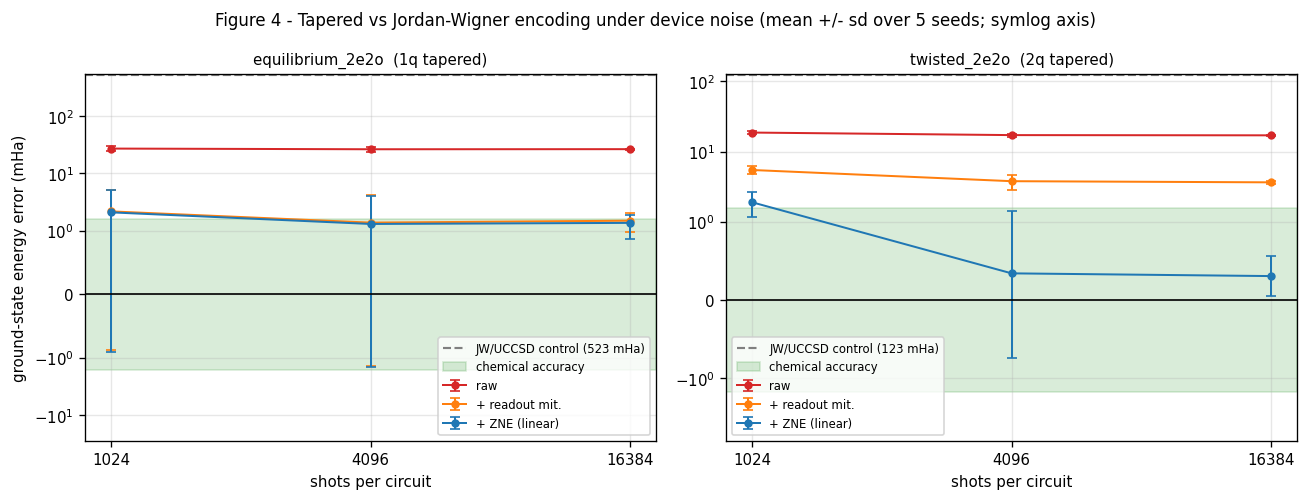

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, key in zip(axes, NOISE_SYSTEMS):
    x = np.arange(len(SHOT_LEVELS))
    for col, lbl, colour in [("e_raw", "raw", "tab:red"),
                             ("e_readout", "+ readout mit.", "tab:orange"),
                             ("e_zne_linear", "+ ZNE (linear)", "tab:blue")]:
        mu = [summary[(key, "tapered", sh)][col][0] for sh in SHOT_LEVELS]
        sd = [summary[(key, "tapered", sh)][col][1] for sh in SHOT_LEVELS]
        ax.errorbar(x, mu, yerr=sd, marker="o", ms=4, capsize=3, lw=1.2,
                    color=colour, label=lbl)
    ctrl = summary.get((key, "jw_uccsd", SHOT_LEVELS[-1]))
    if ctrl:
        ax.axhline(ctrl["e_readout"][0], color="tab:grey", ls="--", lw=1.3,
                   label=f"JW/UCCSD control ({ctrl['e_readout'][0]:.0f} mHa)")
    ax.axhline(0, color="k", lw=1)
    ax.axhspan(-CHEMICAL_ACCURACY_HA * 1e3, CHEMICAL_ACCURACY_HA * 1e3,
               color="green", alpha=0.15, label="chemical accuracy")
    ax.set_xticks(x); ax.set_xticklabels(SHOT_LEVELS)
    ax.set_xlabel("shots per circuit")
    ax.set_title(f"{key}  ({NOISE_PREP[key]['n_qubits']}q tapered)", fontsize=9)
    ax.set_yscale("symlog", linthresh=1.0)
    ax.legend(fontsize=7)
axes[0].set_ylabel("ground-state energy error (mHa)")
fig.suptitle("Figure 4 - Tapered vs Jordan-Wigner encoding under device noise "
             "(mean +/- sd over 5 seeds; symlog axis)", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "fig4_noise_ground_state.png", bbox_inches="tight")
plt.show()

## 4.6 — Optimizing *under* noise

In [165]:
key = "equilibrium_2e2o"
s = SYSTEMS[key]
prep = NOISE_PREP[key]
ansatz = prep["ansatz"]
n_q = prep["n_qubits"]
assign = assignment_for(n_q)
H_labels = [_split_phase(l)[1] for l in prep["H"].paulis.to_labels()]
NOISY_MAXITER, NOISY_SHOTS = 120, 4096
noisy_hist = []

def noisy_cost(x):
    circ = device_transpile(ansatz.assign_parameters(x))
    vals, _ = measure_pauli_set(circ, H_labels, shots=NOISY_SHOTS, seed=SEED,
                                mitigate=True, assignment=assign)
    e = observable_from_values(prep["H"], vals) + s.shift
    noisy_hist.append(e)
    return e

t0 = time.time()
res_noisy = minimize(noisy_cost,
                     np.random.default_rng(SEED).normal(0, 0.3,
                                                        ansatz.num_parameters),
                     method="COBYLA", options={"maxiter": NOISY_MAXITER})
best_noisy = float(np.min(noisy_hist))

print(f"noisy re-optimization: {len(noisy_hist)} evaluations in {time.time()-t0:.1f} s")
print(f"  final energy          {res_noisy.fun:.6f} Ha   "
      f"(error {(res_noisy.fun - s.e_exact)*1e3:+.2f} mHa)")
print(f"  best seen             {best_noisy:.6f} Ha   "
      f"(error {(best_noisy - s.e_exact)*1e3:+.2f} mHa)")
print(f"  noiseless (tapered)   {prep['energy']:.6f} Ha")
print(f"  exact                 {s.e_exact:.6f} Ha")
STORE["noisy_reoptimization"] = dict(
    system=key, shots=NOISY_SHOTS, n_eval=len(noisy_hist),
    e_final=float(res_noisy.fun), e_best=best_noisy, e_exact=float(s.e_exact),
    history=[float(h) for h in noisy_hist])

noisy re-optimization: 25 evaluations in 3.5 s
  final energy          -77.118230 Ha   (error -1.64 mHa)
  best seen             -77.118230 Ha   (error -1.64 mHa)
  noiseless (tapered)   -77.116592 Ha
  exact                 -77.116592 Ha


## 4.7 — QSE under noise: the two results that matter

In [166]:
QSE_NOISE_SHOTS = [4096, 16384]
QSE_NOISE_SEEDS = 3
QSE_NOISE_THRESHOLDS = [1e-6, 1e-3, 1e-2, 5e-2, 1e-1]
qse_noise_rows = []

for key in NOISE_SYSTEMS:
    s = SYSTEMS[key]
    ref_hw = best_singlet_state(key, ansatz_filter="HEA(EfficientSU2)")
    state = device_transpile(ref_hw["circuit"])

    ops, labels = excitation_pool(s, include_doubles=False)
    n_ops = len(ops)

    Hprod = [[(ops[i].adjoint() @ s.H_qubit @ ops[j]).simplify()
              for j in range(n_ops)] for i in range(n_ops)]
    Sprod = [[(ops[i].adjoint() @ ops[j]).simplify()
              for j in range(n_ops)] for i in range(n_ops)]

    needed = set()
    for M in (Hprod, Sprod):
        for row in M:
            for spo in row:
                needed.update(_split_phase(l)[1] for l in spo.paulis.to_labels())
    needed = sorted(needed)

    e_ex, s2_ex = EXACT_SPECTRA[key]
    bright = [i for i in range(1, len(e_ex)) if abs(s2_ex[i]) < 0.2]
    ref_de = (e_ex[bright[0]] - e_ex[0]) * HARTREE_TO_EV if bright else np.nan

    for shots in QSE_NOISE_SHOTS:
        for sd_i in range(QSE_NOISE_SEEDS):
            sd = SEED + 7919 * sd_i
            vals, n_circ = measure_pauli_set(state, needed, shots=shots, seed=sd,
                                             mitigate=True, assignment=ASSIGNMENT_M)
            Hn = np.array([[observable_from_values(Hprod[i][j], vals)
                            for j in range(n_ops)] for i in range(n_ops)])
            Sn = np.array([[observable_from_values(Sprod[i][j], vals)
                            for j in range(n_ops)] for i in range(n_ops)])
            row = dict(system=key, shots=shots, seed=sd, n_paulis=len(needed),
                       n_circuits=n_circ, reference_dE_eV=float(ref_de))
            for th in QSE_NOISE_THRESHOLDS:
                try:
                    en, vecs, info = solve_qse(Hn, Sn, threshold=th)
                    en = en + s.shift
                    de = (en[1] - en[0]) * HARTREE_TO_EV if len(en) > 1 else np.nan
                    row[f"E0_th{th:g}"] = float(en[0])
                    row[f"dE_th{th:g}"] = float(de)
                    row[f"kept_th{th:g}"] = info["n_kept"]
                    row[f"variational_th{th:g}"] = bool(en[0] >= s.e_exact - 1e-9)
                except Exception as exc:
                    row[f"E0_th{th:g}"] = np.nan; row[f"dE_th{th:g}"] = np.nan
                    row[f"kept_th{th:g}"] = 0; row[f"variational_th{th:g}"] = False
            qse_noise_rows.append(row)

STORE["noise_qse"] = qse_noise_rows
print(f"noisy QSE: {len(qse_noise_rows)} runs, "
      f"{qse_noise_rows[0]['n_paulis']} unique Paulis measured in "
      f"{qse_noise_rows[0]['n_circuits']} circuits per run")

noisy QSE: 12 runs, 64 unique Paulis measured in 25 circuits per run


In [167]:
hdr = (f"{'system':<20}{'shots':>7}{'thresh':>9}{'kept':>6}"
       f"{'E0 err (mHa)':>14}{'dE err (eV)':>13}{'variational':>13}")
print(hdr); print("-" * len(hdr))
cancel_rows = []
for key in NOISE_SYSTEMS:
    s = SYSTEMS[key]
    for shots in QSE_NOISE_SHOTS:
        for th in QSE_NOISE_THRESHOLDS:
            sel = [r for r in qse_noise_rows if r["system"] == key and r["shots"] == shots]
            e0 = np.array([r[f"E0_th{th:g}"] for r in sel], float)
            de = np.array([r[f"dE_th{th:g}"] for r in sel], float)
            kept = np.mean([r[f"kept_th{th:g}"] for r in sel])
            var_ok = all(r[f"variational_th{th:g}"] for r in sel)
            ref = sel[0]["reference_dE_eV"]
            e0_err = np.nanmean(e0 - s.e_exact) * 1e3
            de_err = np.nanmean(de - ref)
            print(f"{key:<20}{shots:>7}{th:>9.0e}{kept:>6.1f}"
                  f"{e0_err:>14.2f}{de_err:>13.3f}{str(var_ok):>13}")
            cancel_rows.append(dict(system=key, shots=shots, threshold=th,
                                    kept=float(kept), e0_err_mHa=float(e0_err),
                                    dE_err_eV=float(de_err), variational=bool(var_ok)))
STORE["noise_qse_summary"] = cancel_rows

system                shots   thresh  kept  E0 err (mHa)  dE err (eV)  variational
----------------------------------------------------------------------------------
equilibrium_2e2o       4096    1e-06   5.0         32.23      -10.259         True
equilibrium_2e2o       4096    1e-03   5.0         32.23      -10.259         True
equilibrium_2e2o       4096    1e-02   4.3         32.95      -10.260         True
equilibrium_2e2o       4096    5e-02   3.0         33.70      -10.253         True
equilibrium_2e2o       4096    1e-01   3.0         33.70      -10.253         True
equilibrium_2e2o      16384    1e-06   5.0         31.78      -10.190         True
equilibrium_2e2o      16384    1e-03   5.0         31.78      -10.190         True
equilibrium_2e2o      16384    1e-02   5.0         31.78      -10.190         True
equilibrium_2e2o      16384    5e-02   3.0         32.06      -10.071         True
equilibrium_2e2o      16384    1e-01   3.0         32.06      -10.071         True
twis

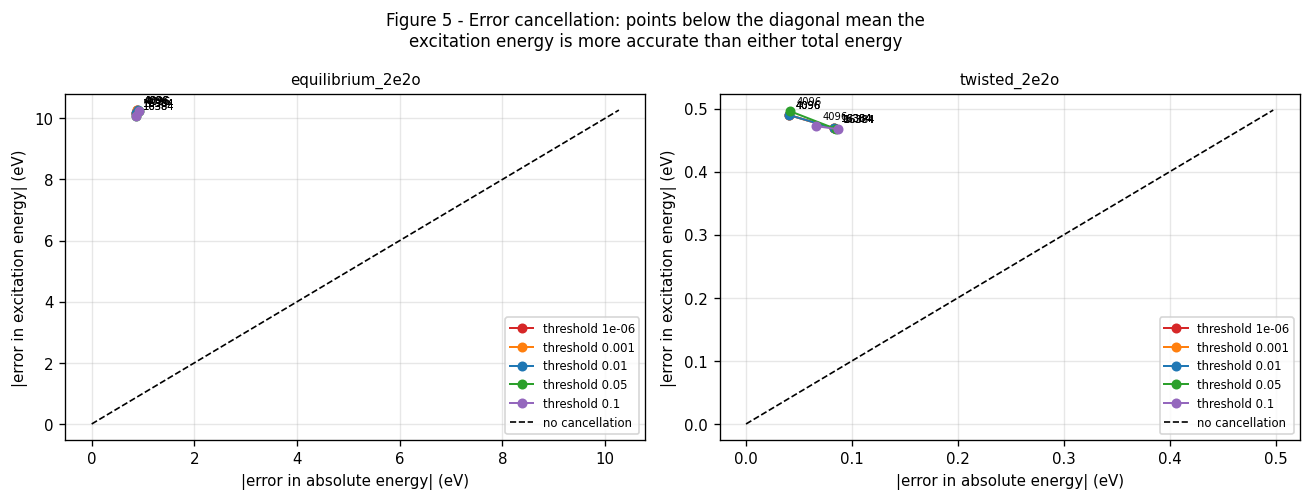

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, key in zip(axes, NOISE_SYSTEMS):
    s = SYSTEMS[key]
    for th, colour in zip(QSE_NOISE_THRESHOLDS,
                          ["tab:red", "tab:orange", "tab:blue", "tab:green",
                           "tab:purple"]):
        xs, ys = [], []
        for shots in QSE_NOISE_SHOTS:
            sel = [r for r in qse_noise_rows if r["system"] == key and r["shots"] == shots]
            e0 = np.nanmean([r[f"E0_th{th:g}"] for r in sel]) - s.e_exact
            de = np.nanmean([r[f"dE_th{th:g}"] for r in sel]) - sel[0]["reference_dE_eV"]
            xs.append(abs(e0) * HARTREE_TO_EV)
            ys.append(abs(de))
        ax.plot(xs, ys, "o-", color=colour, ms=5, lw=1.2, label=f"threshold {th:g}")
        for xv, yv, sh in zip(xs, ys, QSE_NOISE_SHOTS):
            ax.annotate(f"{sh}", (xv, yv), fontsize=6,
                        textcoords="offset points", xytext=(4, 4))
    lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([0, lim], [0, lim], "k--", lw=1, label="no cancellation")
    ax.set_xlabel("|error in absolute energy| (eV)")
    ax.set_ylabel("|error in excitation energy| (eV)")
    ax.set_title(key, fontsize=9); ax.legend(fontsize=7)

fig.suptitle("Figure 5 - Error cancellation: points below the diagonal mean the\n"
             "excitation energy is more accurate than either total energy", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "fig5_error_cancellation.png", bbox_inches="tight")
plt.show()

In [169]:
n_h = len(SYSTEMS["equilibrium_2e2o"].H_qubit)
n_pauli_qse = qse_noise_rows[0]["n_paulis"]
n_circ_qse = qse_noise_rows[0]["n_circuits"]
_jw_rows = [r for r in noise_rows if r["encoding"] == "jw_uccsd"]
n_circ_vqe = (_jw_rows or noise_rows)[0]["n_circuits"]

print(f"Measurement cost, 2e/2o singles-only QSE pool "
      f"({SYSTEMS[NOISE_SYSTEMS[0]].n_qubits} qubits, untapered):\n")
print(f"  Hamiltonian Pauli terms                 {n_h:>6}")
print(f"  circuits for one VQE energy             {n_circ_vqe:>6}")
print(f"  unique Paulis across all QSE H_ij, S_ij {n_pauli_qse:>6}")
print(f"  circuits for one full QSE matrix build  {n_circ_qse:>6}")
print(f"  QSE overhead factor                     {n_circ_qse / max(n_circ_vqe,1):>6.1f}x")
print(f"  ZNE multiplies this by                  {len(ZNE_SCALES):>6}x")
print(f"  readout calibration (one-off)           {2**N_NOISE_QUBITS:>6} circuits")
STORE["measurement_budget"] = dict(
    hamiltonian_terms=int(n_h), circuits_per_vqe_energy=int(n_circ_vqe),
    unique_paulis_qse=int(n_pauli_qse), circuits_per_qse_build=int(n_circ_qse),
    zne_multiplier=len(ZNE_SCALES), readout_cal_circuits=int(2**N_NOISE_QUBITS))

Measurement cost, 2e/2o singles-only QSE pool (4 qubits, untapered):

  Hamiltonian Pauli terms                     15
  circuits for one VQE energy                  5
  unique Paulis across all QSE H_ij, S_ij     64
  circuits for one full QSE matrix build      25
  QSE overhead factor                        5.0x
  ZNE multiplies this by                       3x
  readout calibration (one-off)               16 circuits


---
## 4.8 — Execution on IBM Quantum hardware

In [170]:
RUN_ON_HARDWARE   = True
HW_SYSTEMS        = ["equilibrium_2e2o", "twisted_2e2o"]
HW_SHOTS          = 4096
HW_REPEATS        = 3
HW_ZNE_SCALES     = [1, 3, 5]
HW_OPT_LEVEL      = 1

def _ibm_token():
    tok = os.environ.get("IBM_QUANTUM_TOKEN", "")
    if tok:
        return tok
    try:
        from google.colab import userdata
        return userdata.get("IBM_QUANTUM_TOKEN")
    except Exception:
        return ""

print(f"RUN_ON_HARDWARE = {RUN_ON_HARDWARE}")
print(f"systems         = {HW_SYSTEMS}")
print(f"shots           = {HW_SHOTS} x {HW_REPEATS} repeats, ZNE scales {HW_ZNE_SCALES}")
print(f"token found     = {bool(_ibm_token())}   (value never printed)")

RUN_ON_HARDWARE = True
systems         = ['equilibrium_2e2o', 'twisted_2e2o']
shots           = 4096 x 3 repeats, ZNE scales [1, 3, 5]
token found     = True   (value never printed)


In [171]:
HW_PREP = {}
hdr = (f"{'system':<20}{'tapered q':>11}{'reps':>6}{'params':>8}"
       f"{'noiseless err':>15}{'E_exact':>16}")
print(hdr); print("-" * len(hdr))
for key in HW_SYSTEMS:
    if key not in NOISE_PREP:
        NOISE_PREP[key] = prepare_tapered(SYSTEMS[key])
    prep = NOISE_PREP[key]
    HW_PREP[key] = prep
    print(f"{key:<20}{prep['n_qubits']:>11}{prep['reps']:>6}"
          f"{prep['ansatz'].num_parameters:>8}{prep['error']:>15.2e}"
          f"{prep['system'].e_exact:>16.8f}")

system                tapered q  reps  params  noiseless err         E_exact
----------------------------------------------------------------------------
equilibrium_2e2o              1     1       2       6.26e-11    -77.11659188
twisted_2e2o                  2     4      10       3.64e-08    -76.97948728


In [172]:
def hardware_circuit_set(prep, zne_scales, n_qubits):
    state = prep["ansatz"].assign_parameters(prep["x"])
    spo = prep["H"]
    non_id = [_split_phase(l)[1] for l in spo.paulis.to_labels()]
    non_id = sorted({l for l in non_id if set(l) != {"I"}})

    circuits, meta = [], []
    if non_id:
        bundle = SparsePauliOp(non_id, coeffs=np.ones(len(non_id)))
        for scale in zne_scales:
            folded = fold_global(state, scale)
            for g in bundle.group_commuting(qubit_wise=True):
                basis = group_basis(g, n_qubits)
                circuits.append(measurement_circuit(folded, basis))
                meta.append(dict(kind="energy", scale=scale,
                                 labels=[_split_phase(r)[1]
                                         for r in g.paulis.to_labels()]))
    for i in range(2 ** n_qubits):
        qc = QuantumCircuit(n_qubits)
        for q in range(n_qubits):
            if (i >> q) & 1:
                qc.x(q)
        qc.measure_all()
        circuits.append(qc)
        meta.append(dict(kind="calibration", prepared=i))
    return circuits, meta


HW_CIRCUITS, HW_META, total_circ = {}, {}, 0
for key in HW_SYSTEMS:
    prep = HW_PREP[key]
    c, m = hardware_circuit_set(prep, HW_ZNE_SCALES, prep["n_qubits"])
    HW_CIRCUITS[key], HW_META[key] = c, m
    n_energy = sum(1 for x in m if x["kind"] == "energy")
    n_cal = sum(1 for x in m if x["kind"] == "calibration")
    print(f"{key:<20} {prep['n_qubits']}q   energy circuits {n_energy:>3}   "
          f"calibration {n_cal:>3}   total {len(c):>3}")
    total_circ += len(c)

total_pubs = total_circ * HW_REPEATS
total_shots = total_pubs * HW_SHOTS
STORE["hardware_budget"] = dict(circuits=int(total_circ), repeats=int(HW_REPEATS),
                                pubs=int(total_pubs), shots=int(total_shots),
                                shots_per_circuit=int(HW_SHOTS))

equilibrium_2e2o     1q   energy circuits   6   calibration   2   total   8
twisted_2e2o         2q   energy circuits  12   calibration   4   total  16


In [173]:
def decode_energy(prep, counts_by_index, meta, n_qubits, shots,
                  assignment=None, zne_scales=(1,)):
    per_scale = {}
    for idx, m in enumerate(meta):
        if m["kind"] != "energy":
            continue
        probs = counts_to_probs(counts_by_index[idx], n_qubits, shots)
        if assignment is not None:
            probs = mitigate_probs(probs, assignment)
        vals = per_scale.setdefault(m["scale"], {})
        for lab in m["labels"]:
            vals[lab] = pauli_expval_from_probs(probs, lab, n_qubits)
    energies = {}
    for scale, vals in per_scale.items():
        vals.setdefault("I" * n_qubits, 1.0)
        energies[scale] = observable_from_values(prep["H"], vals) + prep["system"].shift
    scales = sorted(energies)
    ladder = [energies[s] for s in scales]
    lin, exp_ = extrapolate(scales, ladder) if len(scales) > 1 else (ladder[0], np.nan)
    return dict(per_scale=energies, zne_linear=lin, zne_exp=exp_)


def assignment_from_counts(counts_by_index, meta, n_qubits, shots):
    M = np.zeros((2 ** n_qubits, 2 ** n_qubits))
    for idx, m in enumerate(meta):
        if m["kind"] == "calibration":
            M[:, m["prepared"]] = counts_to_probs(counts_by_index[idx], n_qubits, shots)
    return M


print("Dry run on the Aer noise model (same circuits, same decoding):\n")
hdr = f"{'system':<20}{'raw':>14}{'+readout':>14}{'+ZNE(lin)':>14}{'exact':>16}"
print(hdr); print("-" * len(hdr))
dry_rows = []
for key in HW_SYSTEMS:
    prep, circuits, meta = HW_PREP[key], HW_CIRCUITS[key], HW_META[key]
    n = prep["n_qubits"]
    tqcs = [device_transpile(c, optimization_level=HW_OPT_LEVEL) for c in circuits]
    res = NOISY_SIM.run(tqcs, shots=HW_SHOTS, seed_simulator=SEED).result()
    counts = {i: res.get_counts(i) for i in range(len(tqcs))}

    M = assignment_from_counts(counts, meta, n, HW_SHOTS)
    raw = decode_energy(prep, counts, meta, n, HW_SHOTS, None, HW_ZNE_SCALES)
    mit = decode_energy(prep, counts, meta, n, HW_SHOTS, M, HW_ZNE_SCALES)
    e_ex = prep["system"].e_exact
    print(f"{key:<20}{raw['per_scale'][1]:>14.6f}{mit['per_scale'][1]:>14.6f}"
          f"{mit['zne_linear']:>14.6f}{e_ex:>16.6f}")
    dry_rows.append(dict(system=key, raw=raw["per_scale"][1],
                         readout=mit["per_scale"][1], zne=mit["zne_linear"],
                         exact=float(e_ex)))
STORE["hardware_dry_run"] = dry_rows

print("\nErrors vs exact (mHa):")
for r in dry_rows:
    print(f"  {r['system']:<20} raw {(r['raw']-r['exact'])*1e3:+9.2f}   "
          f"+readout {(r['readout']-r['exact'])*1e3:+9.2f}   "
          f"+ZNE {(r['zne']-r['exact'])*1e3:+9.2f}")
print(f"\nChemical accuracy is {CHEMICAL_ACCURACY_HA*1e3:.2f} mHa.")

Dry run on the Aer noise model (same circuits, same decoding):

system                         raw      +readout     +ZNE(lin)           exact
------------------------------------------------------------------------------
equilibrium_2e2o        -77.092353    -77.119172    -77.120248      -77.116592
twisted_2e2o            -76.959356    -76.972347    -76.977413      -76.979487

Errors vs exact (mHa):
  equilibrium_2e2o     raw    +24.24   +readout     -2.58   +ZNE     -3.66
  twisted_2e2o         raw    +20.13   +readout     +7.14   +ZNE     +2.07

Chemical accuracy is 1.59 mHa.


In [174]:
HW_RESULTS = {}
HW_JOB = {}

if not RUN_ON_HARDWARE:
    print("RUN_ON_HARDWARE is False - nothing submitted.")
else:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    try:
        service = QiskitRuntimeService()
    except Exception:
        tok = _ibm_token()
        if not tok:
            raise RuntimeError(
                "No IBM credentials. Set IBM_QUANTUM_TOKEN (env var or Colab "
                "secret), or run QiskitRuntimeService.save_account(...) once.")
        try:
            service = QiskitRuntimeService(channel="ibm_quantum_platform", token=tok)
        except Exception:                  # older accounts on the retired channel
            service = QiskitRuntimeService(channel="ibm_quantum", token=tok)

    need = max(HW_PREP[k]["n_qubits"] for k in HW_SYSTEMS)
    backend = service.least_busy(operational=True, simulator=False,
                                 min_num_qubits=max(need, 5))
    print(f"backend: {backend.name}  ({backend.num_qubits} qubits, "
          f"basis {list(backend.operation_names)})")

    pm = generate_preset_pass_manager(optimization_level=HW_OPT_LEVEL,
                                      backend=backend, seed_transpiler=SEED)
    pubs, index = [], []
    for key in HW_SYSTEMS:
        isa = pm.run(HW_CIRCUITS[key])
        depths = [c.depth() for c in isa]
        print(f"  {key:<20} {len(isa)} ISA circuits, depth "
              f"{min(depths)}-{max(depths)}")
        for rep in range(HW_REPEATS):
            for i, c in enumerate(isa):
                pubs.append((c,))
                index.append((key, rep, i))

    sampler = SamplerV2(mode=backend)
    job = sampler.run(pubs, shots=HW_SHOTS)
    job_id = job.job_id()
    HW_JOB = dict(job_id=job_id, backend=backend.name, index=index,
                  shots=HW_SHOTS, repeats=HW_REPEATS, systems=list(HW_SYSTEMS))
    (RESULTS / "hardware_job.json").write_text(
        json.dumps({k: v for k, v in HW_JOB.items() if k != "index"}, indent=2),
        encoding="utf-8")
    print(f"\nsubmitted {len(pubs)} PUBs as job {job_id} on {backend.name}")
    print(f"job id saved to {RESULTS/'hardware_job.json'}")
    HW_RAW = job.result()
    print("done")

qiskit_runtime_service._discover_account:WARNING:2026-09-07 22:13:52,978: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-09-07 22:13:56,302: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-07 22:13:56,540: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-07 22:13:58,368: Using instance: open-instance, plan: open


backend: ibm_fez  (156 qubits, basis ['id', 'measure', 'measure_2', 'measure_reset_2', 'x', 'if_else', 'cz', 'reset_2', 'measure_reset', 'reset', 'sx', 'delay', 'rz'])
  equilibrium_2e2o     8 ISA circuits, depth 1-21
  twisted_2e2o         16 ISA circuits, depth 1-121

submitted 72 PUBs as job dafjea3dd5gc73d9tp4g on ibm_fez
job id saved to results/hardware_job.json
done


In [176]:
RECOVER_JOB_ID = job_id

if RECOVER_JOB_ID:
    job = service.job(RECOVER_JOB_ID)
    print(f"job {RECOVER_JOB_ID}: status = {job.status()}")
    HW_RAW = job.result()
    saved = json.loads((RESULTS / "hardware_job.json").read_text(encoding="utf-8"))
    print("reloaded:", saved)
else:
    print("RECOVER_JOB_ID is empty - nothing to recover.")

job dafjea3dd5gc73d9tp4g: status = DONE
reloaded: {'job_id': 'dafjea3dd5gc73d9tp4g', 'backend': 'ibm_fez', 'shots': 4096, 'repeats': 3, 'systems': ['equilibrium_2e2o', 'twisted_2e2o']}


In [177]:
def _pub_counts(pub_result):
    data = pub_result.data
    for name in ("meas", "c", "cr", "c0"):
        if hasattr(data, name):
            return getattr(data, name).get_counts()
    for name in dir(data):                       # last resort: the only BitArray
        if name.startswith("_"):
            continue
        obj = getattr(data, name)
        if hasattr(obj, "get_counts"):
            return obj.get_counts()
    raise RuntimeError("could not find a classical register in the PUB result")


if not HW_JOB and not RECOVER_JOB_ID:
    print("No hardware result in this session. Run 4.8.5 or 4.8.6 first.")
else:
    counts_by = {}
    for pub_idx, (key, rep, i) in enumerate(HW_JOB["index"]):
        counts_by.setdefault((key, rep), {})[i] = _pub_counts(HW_RAW[pub_idx])

    hw_rows = []
    for key in HW_SYSTEMS:
        prep, meta = HW_PREP[key], HW_META[key]
        n, e_ex = prep["n_qubits"], prep["system"].e_exact
        for rep in range(HW_JOB["repeats"]):
            cts = counts_by[(key, rep)]
            M = assignment_from_counts(cts, meta, n, HW_JOB["shots"])
            raw = decode_energy(prep, cts, meta, n, HW_JOB["shots"], None, HW_ZNE_SCALES)
            mit = decode_energy(prep, cts, meta, n, HW_JOB["shots"], M, HW_ZNE_SCALES)
            hw_rows.append(dict(
                system=key, repeat=rep, n_qubits=n, exact=float(e_ex),
                raw=raw["per_scale"][1], readout=mit["per_scale"][1],
                zne_linear=mit["zne_linear"], zne_exp=mit["zne_exp"],
                readout_fidelity=float(np.mean(np.diag(M))),
                ladder={str(k): v for k, v in mit["per_scale"].items()}))
    STORE["hardware_results"] = hw_rows
    STORE["hardware_job"] = {k: v for k, v in HW_JOB.items() if k != "index"}

    hdr = (f"{'system':<20}{'q':>3}{'raw err':>14}{'+readout':>14}"
           f"{'+ZNE(lin)':>14}{'RO fidelity':>13}")
    print(f"backend {HW_JOB['backend']}, {HW_JOB['shots']} shots x "
          f"{HW_JOB['repeats']} repeats\n")
    print(hdr); print("-" * len(hdr))
    for key in HW_SYSTEMS:
        sel = [r for r in hw_rows if r["system"] == key]
        f = lambda col: (np.mean([r[col] - r["exact"] for r in sel]) * 1e3,
                         np.std([r[col] - r["exact"] for r in sel]) * 1e3)
        fmt = lambda t: f"{t[0]:+7.2f}+-{t[1]:<5.2f}"
        print(f"{key:<20}{sel[0]['n_qubits']:>3}{fmt(f('raw')):>14}"
              f"{fmt(f('readout')):>14}{fmt(f('zne_linear')):>14}"
              f"{np.mean([r['readout_fidelity'] for r in sel]):>13.4f}")
    print("\nAll errors in mHa against exact diagonalisation of the same active")
    print(f"space. Chemical accuracy is {CHEMICAL_ACCURACY_HA*1e3:.2f} mHa.")

backend ibm_fez, 4096 shots x 3 repeats

system                q       raw err      +readout     +ZNE(lin)  RO fidelity
------------------------------------------------------------------------------
equilibrium_2e2o      1 +41.54+-2.91   +3.09+-3.05   +4.57+-1.02        0.9489
twisted_2e2o          2 +41.68+-1.20  +26.80+-1.17   -6.04+-1.33        0.9234

All errors in mHa against exact diagonalisation of the same active
space. Chemical accuracy is 1.59 mHa.


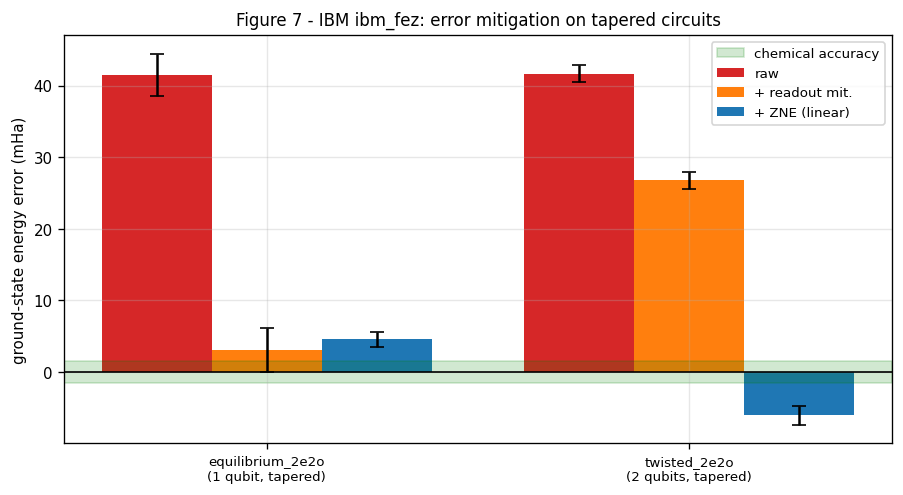

In [178]:
if STORE.get("hardware_results"):
    hw_rows = STORE["hardware_results"]
    fig, ax = plt.subplots(figsize=(7.6, 4.2))
    width, xs = 0.26, np.arange(len(HW_SYSTEMS))
    for off, (col, lbl, colour) in zip(
            (-width, 0.0, width),
            [("raw", "raw", "tab:red"),
             ("readout", "+ readout mit.", "tab:orange"),
             ("zne_linear", "+ ZNE (linear)", "tab:blue")]):
        mu = [np.mean([(r[col] - r["exact"]) * 1e3
                       for r in hw_rows if r["system"] == k]) for k in HW_SYSTEMS]
        sd = [np.std([(r[col] - r["exact"]) * 1e3
                      for r in hw_rows if r["system"] == k]) for k in HW_SYSTEMS]
        ax.bar(xs + off, mu, width, yerr=sd, capsize=4, color=colour, label=lbl)
    ax.axhline(0, color="k", lw=1)
    ax.axhspan(-CHEMICAL_ACCURACY_HA * 1e3, CHEMICAL_ACCURACY_HA * 1e3,
               color="green", alpha=0.18, label="chemical accuracy")
    ax.set_xticks(xs)
    ax.set_xticklabels([f"{k}\n({HW_PREP[k]['n_qubits']} qubit"
                        f"{'s' if HW_PREP[k]['n_qubits'] > 1 else ''}, tapered)"
                        for k in HW_SYSTEMS], fontsize=8)
    ax.set_ylabel("ground-state energy error (mHa)")
    ax.set_title(f"Figure 7 - IBM {STORE['hardware_job']['backend']}: "
                 f"error mitigation on tapered circuits", fontsize=10)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES / "fig7_hardware.png", bbox_inches="tight")
    plt.show()
else:
    print("No hardware results yet - figure 7 will be generated after 4.8.7.")

In [179]:
metrics = job.metrics()
print(json.dumps(metrics, indent=2, default=str))
print(
    "QPU usage:",
    metrics.get("usage", {}).get("quantum_seconds"),
    "seconds"
)

(RESULTS / "hardware_results.json").write_text(
    json.dumps(
        {
            "job": STORE["hardware_job"],
            "metrics": metrics,
            "results": STORE["hardware_results"],
        },
        indent=2,
        default=_json_default,
    ),
    encoding="utf-8",
)

{
  "caller": "qiskit_ibm_runtime~sampler.py",
  "qiskit_version": "qiskit_ibm_runtime-0.49.0,qiskit-2.5.2*,qiskit_aer-0.17.2",
  "timestamps": {
    "created": "2026-09-07T22:14:00.318073Z",
    "finished": "2026-09-07T22:15:33.803417Z",
    "running": "2026-09-07T22:14:01.850628Z"
  },
  "usage": {
    "qpu_charge_time_seconds": 79,
    "status": "complete"
  },
  "circuits_execution_time_ns": 76486938112
}
QPU usage: None seconds


3229

---
# 5 — Classical benchmarking

In [183]:
def classical_suite(atom, basis, ncas, nelecas, nroots=3, state_average=True,
                    do_eom=True, label=""):
    out = dict(label=label, basis=basis, ncas=ncas, nelecas=nelecas)
    mol = gto.M(atom=atom, basis=basis, charge=0, spin=0, verbose=0)
    out["n_basis_functions"] = int(mol.nao_nr())

    mf = scf.RHF(mol); mf.max_cycle = 300; mf.kernel()
    out["e_hf"] = float(mf.e_tot)
    out["hf_converged"] = bool(mf.converged)

    try:
        mc = mcscf.CASCI(mf, ncas, nelecas)
        mc.fcisolver.nroots = nroots
        mc.fcisolver.spin = 0
        mc.kernel()
        e = np.atleast_1d(mc.e_tot)
        out["casci"] = [float(v) for v in e]
        out["casci_exc_eV"] = [float((v - e[0]) * HARTREE_TO_EV) for v in e[1:]]
    except Exception as exc:
        out["casci_error"] = f"{type(exc).__name__}: {exc}"

    try:
        mc2 = mcscf.CASSCF(mf, ncas, nelecas)
        mc2.max_cycle_macro = 200
        mc2.fcisolver.spin = 0
        try:
            mc2.fix_spin_(ss=0)
        except Exception as exc:
            print(f"    (fix_spin_ unavailable: {type(exc).__name__})")
        if state_average and nroots > 1:
            mc2 = mc2.state_average_([1.0 / nroots] * nroots)
        mc2.kernel()
        e2 = np.atleast_1d(getattr(mc2, "e_states", mc2.e_tot))
        out["casscf"] = [float(v) for v in e2]
        out["casscf_exc_eV"] = [float((v - e2[0]) * HARTREE_TO_EV) for v in e2[1:]]
        out["casscf_converged"] = bool(mc2.converged)
    except Exception as exc:
        out["casscf_error"] = f"{type(exc).__name__}: {exc}"

    if do_eom:
        try:
            mycc = cc.CCSD(mf); mycc.max_cycle = 200; mycc.kernel()
            out["e_ccsd"] = float(mycc.e_tot)
            out["ccsd_converged"] = bool(mycc.converged)
            e_s = np.atleast_1d(mycc.eomee_ccsd_singlet(nroots=nroots - 1)[0])
            out["eom_singlet_eV"] = [float(v * HARTREE_TO_EV) for v in e_s]
            e_t = np.atleast_1d(mycc.eomee_ccsd_triplet(nroots=1)[0])
            out["eom_triplet_eV"] = [float(v * HARTREE_TO_EV) for v in e_t]
        except Exception as exc:
            out["eom_error"] = f"{type(exc).__name__}: {exc}"

    return out

In [184]:
same_space = []
for key, s in SYSTEMS.items():
    res = classical_suite(s.atom, "sto-3g", s.n_orb, s.n_elec, nroots=3,
                          state_average=True, do_eom=False, label=key)
    qse_row = next((r for r in STORE["pi_pistar"]
                    if r["system"] == key and r["pool"] == "singles+doubles"), None)
    e_ex, s2_ex = EXACT_SPECTRA[key]
    ex_ref = exact_reference_root(s2_ex)
    bright = [i for i in range(ex_ref + 1, len(e_ex)) if abs(s2_ex[i]) < 0.2]
    exact_de = ((e_ex[bright[0]] - e_ex[ex_ref]) * HARTREE_TO_EV
                if bright else np.nan)
    res["qse_dE_eV"] = qse_row["dE_eV"] if qse_row and qse_row.get("found") else np.nan
    res["exact_dE_eV"] = float(exact_de)
    res["vqe_energy"] = VQE_RESULTS[(key, "UCCSD", "SLSQP")]["energy"]
    same_space.append(res)

hdr = (f"{'system':<20}{'E_CASCI':>15}{'E_VQE':>15}{'dE (mHa)':>11}"
       f"{'CASCI exc':>11}{'QSE exc':>10}{'diff (eV)':>11}")
print(hdr); print("-" * len(hdr))
for r in same_space:
    e_cas = r["casci"][0]
    d_e = (r["vqe_energy"] - e_cas) * 1e3
    cas_exc = r.get("casci_exc_eV", [np.nan])[0]
    print(f"{r['label']:<20}{e_cas:>15.8f}{r['vqe_energy']:>15.8f}{d_e:>11.2e}"
          f"{r['exact_dE_eV']:>11.3f}{r['qse_dE_eV']:>10.3f}"
          f"{r['qse_dE_eV'] - r['exact_dE_eV']:>11.3f}")
STORE["classical_same_space"] = same_space

system                      E_CASCI          E_VQE   dE (mHa)  CASCI exc   QSE exc  diff (eV)
---------------------------------------------------------------------------------------------
equilibrium_2e2o       -77.11659188   -77.11659188   1.22e-07     14.155    14.155      0.000
equilibrium_2e4o       -77.11677748   -77.11677747   1.24e-05     14.160    14.160      0.000
twisted_2e2o           -76.97948728   -76.97692821   2.56e+00      6.580     6.580      0.000
twisted_2e4o           -76.97948728   -76.97692822   2.56e+00      6.524     6.557      0.033


### Active-space convergence (STO-3G)

In [185]:
AS_LADDER = [(2, 2), (2, 4), (4, 4), (6, 6)]
as_rows = []
for label, tors in [("equilibrium", 0.0), ("twisted", 90.0)]:
    atom = ethylene(tors)
    for (ne, no) in AS_LADDER:
        t0 = time.time()
        r = classical_suite(atom, "sto-3g", no, ne, nroots=3, state_average=True,
                            do_eom=False, label=f"{label} ({ne}e,{no}o)")
        r["geometry"] = label; r["wall_s"] = time.time() - t0
        as_rows.append(r)
        casci = r.get("casci_exc_eV", [np.nan])
        casscf = r.get("casscf_exc_eV", [np.nan])
        print(f"{r['label']:<26} CASCI exc1 = {casci[0]:>8.3f} eV   "
              f"SA-CASSCF exc1 = {casscf[0]:>8.3f} eV   ({r['wall_s']:.1f} s)")
STORE["active_space_ladder"] = as_rows

equilibrium (2e,2o)        CASCI exc1 =    4.792 eV   SA-CASSCF exc1 =   14.142 eV   (0.2 s)
equilibrium (2e,4o)        CASCI exc1 =    4.797 eV   SA-CASSCF exc1 =   14.148 eV   (0.3 s)
equilibrium (4e,4o)        CASCI exc1 =    4.802 eV   SA-CASSCF exc1 =   12.468 eV   (0.4 s)
equilibrium (6e,6o)        CASCI exc1 =    4.799 eV   SA-CASSCF exc1 =   12.544 eV   (10.3 s)
twisted (2e,2o)            CASCI exc1 =    0.070 eV   SA-CASSCF exc1 =    5.821 eV   (0.4 s)
twisted (2e,4o)            CASCI exc1 =    0.070 eV   SA-CASSCF exc1 =    5.737 eV   (0.6 s)
twisted (4e,4o)            CASCI exc1 =    0.062 eV   SA-CASSCF exc1 =    5.375 eV   (1.6 s)
twisted (6e,6o)            CASCI exc1 =    0.058 eV   SA-CASSCF exc1 =    5.271 eV   (9.7 s)


### Basis-set convergence at the planar geometry

In [186]:
BASIS_LADDER = ["sto-3g", "6-31g", "6-31+g*", "aug-cc-pvdz"]
basis_rows = []
for basis in BASIS_LADDER:
    t0 = time.time()
    r = classical_suite(ethylene(0.0), basis, 2, 2, nroots=3,
                        state_average=True, do_eom=True, label=f"equilibrium/{basis}")
    r["wall_s"] = time.time() - t0
    basis_rows.append(r)
    casscf = r.get("casscf_exc_eV", [np.nan])[0]
    eom = r.get("eom_singlet_eV", [np.nan])[0]
    print(f"{basis:<14} nbf={r['n_basis_functions']:>4}   "
          f"SA-CASSCF(2,2) = {casscf:>7.3f} eV   EOM-CCSD = {eom:>7.3f} eV   "
          f"({r['wall_s']:.1f} s)")
STORE["basis_ladder"] = basis_rows

print(f"\nExperimental band maximum: {EXPT_PI_PISTAR_EV} eV")

sto-3g         nbf=  14   SA-CASSCF(2,2) =  14.142 eV   EOM-CCSD =  11.609 eV   (0.6 s)
6-31g          nbf=  26   SA-CASSCF(2,2) =  10.785 eV   EOM-CCSD =   9.220 eV   (1.8 s)
6-31+g*        nbf=  44   SA-CASSCF(2,2) =   6.832 eV   EOM-CCSD =   7.795 eV   (5.8 s)
aug-cc-pvdz    nbf=  82   SA-CASSCF(2,2) =   5.748 eV   EOM-CCSD =   7.299 eV   (55.7 s)

Experimental band maximum: 7.66 eV


In [187]:
basis_rows_tw = []
for basis in BASIS_LADDER:
    r = classical_suite(ethylene(90.0), basis, 2, 2, nroots=3,
                        state_average=True, do_eom=True, label=f"twisted/{basis}")
    basis_rows_tw.append(r)
    casscf = r.get("casscf_exc_eV", [np.nan])[0]
    eom = r.get("eom_singlet_eV", [np.nan])[0] if "eom_singlet_eV" in r else np.nan
    ccsd_ok = r.get("ccsd_converged", "n/a")
    print(f"{basis:<14} SA-CASSCF(2,2) = {casscf:>8.3f} eV   "
          f"EOM-CCSD = {eom:>8.3f} eV   CCSD converged = {ccsd_ok}")
STORE["basis_ladder_twisted"] = basis_rows_tw

sto-3g         SA-CASSCF(2,2) =    5.821 eV   EOM-CCSD =    4.945 eV   CCSD converged = True
6-31g          SA-CASSCF(2,2) =    3.539 eV   EOM-CCSD =   -3.199 eV   CCSD converged = True
6-31+g*        SA-CASSCF(2,2) =    3.021 eV   EOM-CCSD =    2.497 eV   CCSD converged = True
aug-cc-pvdz    SA-CASSCF(2,2) =    2.838 eV   EOM-CCSD =    2.131 eV   CCSD converged = True


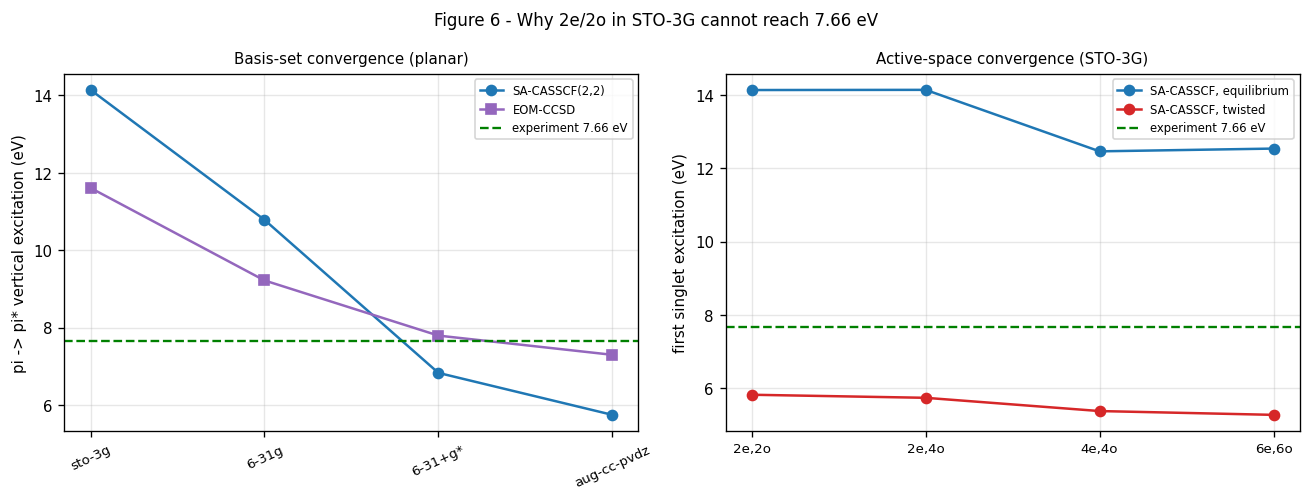

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
x = np.arange(len(BASIS_LADDER))
casscf_vals = [r.get("casscf_exc_eV", [np.nan])[0] for r in basis_rows]
eom_vals = [r.get("eom_singlet_eV", [np.nan])[0] for r in basis_rows]
ax.plot(x, casscf_vals, "o-", label="SA-CASSCF(2,2)", color="tab:blue")
ax.plot(x, eom_vals, "s-", label="EOM-CCSD", color="tab:purple")
ax.axhline(EXPT_PI_PISTAR_EV, color="green", ls="--", lw=1.4, label="experiment 7.66 eV")
ax.set_xticks(x); ax.set_xticklabels(BASIS_LADDER, rotation=25, fontsize=8)
ax.set_ylabel("pi -> pi* vertical excitation (eV)")
ax.set_title("Basis-set convergence (planar)", fontsize=9); ax.legend(fontsize=7)

ax = axes[1]
for geom, colour in [("equilibrium", "tab:blue"), ("twisted", "tab:red")]:
    sel = [r for r in as_rows if r["geometry"] == geom]
    xs = np.arange(len(sel))
    ys = [r.get("casscf_exc_eV", [np.nan])[0] for r in sel]
    ax.plot(xs, ys, "o-", color=colour, label=f"SA-CASSCF, {geom}")
ax.axhline(EXPT_PI_PISTAR_EV, color="green", ls="--", lw=1.4, label="experiment 7.66 eV")
ax.set_xticks(np.arange(len(AS_LADDER)))
ax.set_xticklabels([f"{ne}e,{no}o" for ne, no in AS_LADDER], fontsize=8)
ax.set_ylabel("first singlet excitation (eV)")
ax.set_title("Active-space convergence (STO-3G)", fontsize=9); ax.legend(fontsize=7)

fig.suptitle("Figure 6 - Why 2e/2o in STO-3G cannot reach 7.66 eV", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "fig6_classical_convergence.png", bbox_inches="tight")
plt.show()

In [189]:
qse_row = next(r for r in STORE["pi_pistar"]
               if r["system"] == "equilibrium_2e2o" and r["pool"] == "singles+doubles")
e_qse = qse_row["dE_eV"]
e_exact_small = qse_row["exact_eV"]
e_best_classical = min(
    [v for v in [basis_rows[-1].get("eom_singlet_eV", [np.nan])[0],
                 basis_rows[-1].get("casscf_exc_eV", [np.nan])[0]] if np.isfinite(v)],
    key=lambda v: abs(v - EXPT_PI_PISTAR_EV))

print("Decomposition of the total error in the pi -> pi* excitation energy\n")
print(f"  QSE (2e/2o, STO-3G)                      {e_qse:>8.3f} eV")
print(f"  exact diagonalisation, same active space {e_exact_small:>8.3f} eV")
print(f"  best classical here (aug-cc-pVDZ)        {e_best_classical:>8.3f} eV")
print(f"  experiment                               {EXPT_PI_PISTAR_EV:>8.3f} eV")
print()
print(f"  (a) QSE subspace truncation error        {e_qse - e_exact_small:>+8.3f} eV")
print(f"  (b) active space + basis-set error       {e_best_classical - e_exact_small:>+8.3f} eV")
print(f"  (c) remaining model error vs experiment  {EXPT_PI_PISTAR_EV - e_best_classical:>+8.3f} eV")

STORE["error_decomposition"] = dict(
    qse_eV=float(e_qse), exact_small_space_eV=float(e_exact_small),
    best_classical_eV=float(e_best_classical), experiment_eV=EXPT_PI_PISTAR_EV,
    qse_truncation_eV=float(e_qse - e_exact_small),
    model_chemistry_eV=float(e_best_classical - e_exact_small),
    residual_vs_expt_eV=float(EXPT_PI_PISTAR_EV - e_best_classical))

Decomposition of the total error in the pi -> pi* excitation energy

  QSE (2e/2o, STO-3G)                        14.155 eV
  exact diagonalisation, same active space   14.155 eV
  best classical here (aug-cc-pVDZ)           7.299 eV
  experiment                                  7.660 eV

  (a) QSE subspace truncation error          +0.000 eV
  (b) active space + basis-set error         -6.856 eV
  (c) remaining model error vs experiment    +0.361 eV


---
# 6 — Extension: from excitation energy to electron-transfer rate

The challenge asks for a concrete path from "excitation energy" to "electron
transfer rate" to "photocurrent". The bridge is **Marcus theory**:

$$k_{ET} = \frac{2\pi}{\hbar}\,|H_{DA}|^2\,\frac{1}{\sqrt{4\pi\lambda k_BT}}\,
\exp\!\left[-\frac{(\Delta G^\circ + \lambda)^2}{4\lambda k_BT}\right]$$

Each ingredient maps onto something this pipeline already computes:

| Marcus input | How the pipeline supplies it |
|---|---|
| **ΔG°** driving force | Difference of diabatic donor/acceptor state energies — VQE/QSE energies at fixed geometry |
| **λ** reorganization energy | Standard four-point scheme: the same energies evaluated at donor- and acceptor-optimal geometries |
| **H_DA** electronic coupling | **Generalized Mulliken–Hush**, from the adiabatic energy gap, the transition dipole and the dipole difference — all of which QSE already produces |

The third row is the tight connection and the reason QSE (rather than a
ground-state-only method) is the right base. Solving the QSE generalized
eigenproblem yields subspace eigenvectors; contracting them with the dipole
operator in the *same* subspace gives transition and state dipole moments directly.
Section 3 already computed exactly these to assign oscillator strengths.

$$H_{DA} = \frac{\mu_{tr}\,\Delta E}{\sqrt{(\Delta\mu)^2 + 4\mu_{tr}^2}}$$

In [190]:
KB_HARTREE_PER_K = 3.166811563e-6
AU_TIME_S = 2.4188843265857e-17

def gmh_coupling(delta_E, mu_tr, delta_mu):
    return float(abs(mu_tr) * delta_E / math.sqrt(delta_mu ** 2 + 4.0 * mu_tr ** 2))


def marcus_rate(h_da, lam, dG, T=298.15):
    kT = KB_HARTREE_PER_K * T
    pref = 2.0 * math.pi * h_da ** 2
    rate_au = pref / math.sqrt(4.0 * math.pi * lam * kT) * \
        math.exp(-((dG + lam) ** 2) / (4.0 * lam * kT))
    return float(rate_au / AU_TIME_S)

key = "equilibrium_2e4o"
s = SYSTEMS[key]
res = QSE_RESULTS[(key, "singles+doubles")]
dip_ops = dipole_operators(s)
V, vecs = res["V"], res["vectors"]

if dip_ops:
    dip_sub = {k: V.conj().T @ m @ V for k, m in dip_ops.items()}
    c0 = vecs[:, 0]
    bright = next((r for r in res["rows"][1:]
                   if abs(r["s2_expect"]) < 0.2 and r["osc_strength"] > 1e-6),
                  res["rows"][1])
    ck = vecs[:, bright["root"]]
    mu_tr = math.sqrt(sum(abs(complex(c0.conj() @ m @ ck)) ** 2 for m in dip_sub.values()))
    mu_0 = math.sqrt(sum(abs(complex(c0.conj() @ m @ c0)) ** 2 for m in dip_sub.values()))
    mu_k = math.sqrt(sum(abs(complex(ck.conj() @ m @ ck)) ** 2 for m in dip_sub.values()))
    d_mu = abs(mu_k - mu_0)
    dE = bright["dE_eV"] / HARTREE_TO_EV
    h_da = gmh_coupling(dE, mu_tr, d_mu)

    print("Quantities extracted from the QSE subspace (atomic units):")
    print(f"  adiabatic gap    dE      = {dE:.6f} Ha  ({bright['dE_eV']:.3f} eV)")
    print(f"  transition dipole |mu_tr| = {mu_tr:.6f}")
    print(f"  dipole difference |d_mu|  = {d_mu:.6f}")
    print(f"  GMH coupling      H_DA    = {h_da:.6f} Ha  "
          f"({h_da*HARTREE_TO_EV*1000:.1f} meV)")
    STORE["gmh_demo"] = dict(system=key, dE_ha=float(dE), mu_tr=float(mu_tr),
                             delta_mu=float(d_mu), h_da_ha=float(h_da))

Quantities extracted from the QSE subspace (atomic units):
  adiabatic gap    dE      = 0.520356 Ha  (14.160 eV)
  transition dipole |mu_tr| = 1.323062
  dipole difference |d_mu|  = 0.000000
  GMH coupling      H_DA    = 0.260178 Ha  (7079.8 meV)


In [191]:
lam_eV, dG_eV = 0.30, -0.25
lam, dG = lam_eV / HARTREE_TO_EV, dG_eV / HARTREE_TO_EV

print(f"Marcus rates at lambda = {lam_eV} eV, dG = {dG_eV} eV, T = 298 K\n")
print(f"  {'H_DA (meV)':>12}{'k_ET (s^-1)':>16}{'lifetime':>14}")
print("  " + "-" * 42)
marcus_scan = []
for h_meV in [0.1, 1.0, 5.0, 10.0, 50.0]:
    h = h_meV / 1000.0 / HARTREE_TO_EV
    k = marcus_rate(h, lam, dG)
    tau = 1.0 / k
    unit = f"{tau*1e12:.2f} ps" if tau < 1e-9 else f"{tau*1e9:.2f} ns"
    print(f"  {h_meV:>12.1f}{k:>16.3e}{unit:>14}")
    marcus_scan.append(dict(h_da_meV=h_meV, k_et_s=k, lifetime_s=tau))
STORE["marcus_scan"] = dict(lambda_eV=lam_eV, dG_eV=dG_eV, T=298.15, scan=marcus_scan)

Marcus rates at lambda = 0.3 eV, dG = -0.25 eV, T = 298 K

    H_DA (meV)     k_ET (s^-1)      lifetime
  ------------------------------------------
           0.1       2.828e+08       3.54 ns
           1.0       2.828e+10      35.36 ps
           5.0       7.071e+11       1.41 ps
          10.0       2.828e+12       0.35 ps
          50.0       7.071e+13       0.01 ps


## 6.2 — What it would take to reach a chlorophyll fragment

In [192]:
def resource_estimate(name, n_elec, n_orb, note=""):
    n_so = 2 * n_orb
    n_occ, n_virt = n_elec, n_so - n_elec
    uccsd_params = n_occ * n_virt + (n_occ * (n_occ - 1) // 2) * (n_virt * (n_virt - 1) // 2)
    pauli_terms = n_so ** 4 // 8                    # O(N^4) with symmetry factors
    qse_pool = 1 + n_so ** 2                        # identity + singles
    qse_elements = qse_pool ** 2
    return dict(system=name, active_space=f"{n_elec}e,{n_orb}o", spin_orbitals=n_so,
                jw_qubits=n_so, tapered_estimate=max(n_so - 3, 1),
                uccsd_params=uccsd_params, hamiltonian_pauli_terms=pauli_terms,
                qse_matrix_elements=qse_elements, note=note)


ESTIMATES = [
    resource_estimate("ethylene (this work)", 2, 2, "runs today, 4 qubits"),
    resource_estimate("ethylene (this work)", 2, 4, "runs today, 8 qubits"),
    resource_estimate("butadiene (Sec 6.3)", 4, 4, "runs today, 8 qubits"),
    resource_estimate("benzene pi", 6, 6, "simulable, borderline on hardware"),
    resource_estimate("porphine pi", 24, 24, "far beyond NISQ"),
    resource_estimate("chlorophyll a pi", 26, 26, "far beyond NISQ"),
]

hdr = (f"{'system':<24}{'space':>10}{'JW q':>7}{'tapered':>9}"
       f"{'UCCSD par':>11}{'H terms':>10}{'QSE elts':>10}  note")
print(hdr); print("-" * (len(hdr) + 22))
for e in ESTIMATES:
    print(f"{e['system']:<24}{e['active_space']:>10}{e['jw_qubits']:>7}"
          f"{e['tapered_estimate']:>9}{e['uccsd_params']:>11}"
          f"{e['hamiltonian_pauli_terms']:>10}{e['qse_matrix_elements']:>10}  {e['note']}")
STORE["resource_estimates"] = ESTIMATES

system                       space   JW q  tapered  UCCSD par   H terms  QSE elts  note
-------------------------------------------------------------------------------------------------------------
ethylene (this work)         2e,2o      4        1          5        32       289  runs today, 4 qubits
ethylene (this work)         2e,4o      8        5         27       512      4225  runs today, 8 qubits
butadiene (Sec 6.3)          4e,4o      8        5         52       512      4225  runs today, 8 qubits
benzene pi                   6e,6o     12        9        261      2592     21025  simulable, borderline on hardware
porphine pi                24e,24o     48       45      76752    663552   5313025  far beyond NISQ
chlorophyll a pi           26e,26o     52       49     106301    913952   7317025  far beyond NISQ


## 6.3 — Toy demonstration on butadiene

Butadiene is the natural next rung: a 4-electron / 4-orbital π active space, 8 qubits
under Jordan–Wigner, and the identical pipeline with no changes.

It also makes the singles-vs-doubles point far more sharply than ethylene does.
Butadiene's excited states are the textbook case: the bright 1¹Bᵤ state near 6 eV is
dominated by a *single* excitation, while the dark 2¹Aɡ state nearby has famously
large **doubly-excited** character. A singles-only QSE pool should find the first and
miss the second.

In [193]:
def butadiene_s_trans(cc_double=1.34, cc_single=1.46, ch=1.08, ccc_deg=124.0):
    a = math.radians(ccc_deg)
    C2 = np.array([0.0, 0.0, 0.0])
    C3 = np.array([cc_single, 0.0, 0.0])
    C1 = C2 + cc_double * np.array([math.cos(a), math.sin(a), 0.0])
    centre = 0.5 * (C2 + C3)
    C4 = 2 * centre - C1

    def rot_z(v, deg):
        c, s_ = math.cos(math.radians(deg)), math.sin(math.radians(deg))
        return np.array([c * v[0] - s_ * v[1], s_ * v[0] + c * v[1], 0.0])

    u = (C2 - C1) / np.linalg.norm(C2 - C1)
    H1 = C1 + ch * rot_z(u, +121.0)
    H2 = C1 + ch * rot_z(u, -121.0)

    u1 = (C1 - C2) / np.linalg.norm(C1 - C2)
    u2 = (C3 - C2) / np.linalg.norm(C3 - C2)
    b = -(u1 + u2); b /= np.linalg.norm(b)
    H3 = C2 + ch * b

    H4, H5, H6 = 2 * centre - H3, 2 * centre - H1, 2 * centre - H2
    atoms = [("C", C1), ("C", C2), ("C", C3), ("C", C4),
             ("H", H1), ("H", H2), ("H", H3), ("H", H4), ("H", H5), ("H", H6)]
    return "; ".join(f"{s_} {p[0]:.10f} {p[1]:.10f} {p[2]:.10f}" for s_, p in atoms)


BUTADIENE = butadiene_s_trans()
P = [np.array([float(v) for v in a.split()[1:]]) for a in BUTADIENE.split(";")]
ang = lambda a, b, c: math.degrees(math.acos(np.clip(
    np.dot(a - b, c - b) / (np.linalg.norm(a - b) * np.linalg.norm(c - b)), -1, 1)))
print("butadiene geometry check:")
print(f"  C1=C2 {np.linalg.norm(P[0]-P[1]):.4f} A   C2-C3 {np.linalg.norm(P[1]-P[2]):.4f} A   "
      f"C3=C4 {np.linalg.norm(P[2]-P[3]):.4f} A")
print(f"  C1-C2-C3 {ang(P[0],P[1],P[2]):.2f} deg   C2-C3-C4 {ang(P[1],P[2],P[3]):.2f} deg")
print(f"  planar: max |z| = {max(abs(p[2]) for p in P):.2e} A")

butadiene geometry check:
  C1=C2 1.3400 A   C2-C3 1.4600 A   C3=C4 1.3400 A
  C1-C2-C3 124.00 deg   C2-C3-C4 124.00 deg
  planar: max |z| = 0.00e+00 A


In [194]:
t0 = time.time()
bd = build_system("butadiene", 0.0, n_elec=4, n_orb=4, basis="sto3g", atom=BUTADIENE)
SYSTEMS[bd.key] = bd
SYM_OPS[bd.key] = symmetry_operators(bd)

_, _, e_cas_bd = pyscf_casci(BUTADIENE, "sto3g", 4, 4)
print(f"butadiene 4e/4o: {bd.n_qubits} qubits, {len(bd.H_qubit)} Pauli terms")
print(f"  CASCI(4,4)      {e_cas_bd[0]:.10f} Ha")
print(f"  qubit H exact   {bd.e_exact:.10f} Ha   |diff| = {abs(e_cas_bd[0]-bd.e_exact):.2e}")
assert abs(e_cas_bd[0] - bd.e_exact) < 1e-8, "butadiene validation gate failed"

anz_bd = make_uccsd(bd)
r_bd = run_vqe(bd, anz_bd, method="SLSQP")
print(f"  VQE (UCCSD)     {r_bd['energy']:.10f} Ha   "
      f"error {(r_bd['energy']-bd.e_exact)*1e3:+.4f} mHa   "
      f"({r_bd['n_params']} params, {r_bd['nfev']} evals)")

psi_bd = np.asarray(Statevector(anz_bd.assign_parameters(r_bd["x"])).data)
e_ex_bd, s2_ex_bd, _ = sector_spectrum(bd, SYM_OPS[bd.key])
EXACT_SPECTRA[bd.key] = (e_ex_bd, s2_ex_bd)
dip_bd = dipole_operators(bd)

print(f"\n  {'pool':<17}{'root':>5}{'dE (eV)':>10}{'<S2>':>8}{'f_osc':>9}{'exact dE':>10}")
bd_rows = []
for pool_name, doubles in [("singles", False), ("singles+doubles", True)]:
    ops_bd, _ = excitation_pool(bd, include_doubles=doubles)
    H_bd, S_bd, V_bd = qse_subspace(bd, psi_bd, ops_bd)
    en_bd, vec_bd, info_bd = solve_qse(H_bd, S_bd, threshold=1e-8)
    en_bd = en_bd + bd.shift
    rows = label_roots(bd, V_bd, en_bd, vec_bd, SYM_OPS[bd.key], dip_bd, n_report=5)
    QSE_RESULTS[(bd.key, pool_name)] = dict(rows=rows, info=info_bd, n_ops=len(ops_bd),
                                            energies=en_bd, H=H_bd, S=S_bd, V=V_bd,
                                            vectors=vec_bd, psi=psi_bd)
    for row in rows[1:4]:
        k = row["root"]
        ex = ((e_ex_bd[k] - e_ex_bd[exact_reference_root(s2_ex_bd)])
              * HARTREE_TO_EV if k < len(e_ex_bd) else np.nan)
        print(f"  {pool_name:<17}{k:>5}{row['dE_eV']:>10.3f}{row['s2_expect']:>8.4f}"
              f"{row['osc_strength']:>9.4f}{ex:>10.3f}")
        bd_rows.append(dict(pool=pool_name, **row, exact_dE_eV=float(ex)))
    print()

STORE["butadiene"] = dict(qubits=bd.n_qubits, pauli_terms=len(bd.H_qubit),
                          e_casci=float(e_cas_bd[0]), e_vqe=float(r_bd["energy"]),
                          e_exact=float(bd.e_exact), roots=bd_rows,
                          wall_s=float(time.time() - t0))
print(f"butadiene pipeline completed in {time.time()-t0:.1f} s")

butadiene 4e/4o: 8 qubits, 185 Pauli terms
  CASCI(4,4)      -153.1030034913 Ha
  qubit H exact   -153.1030034913 Ha   |diff| = 8.53e-14
  VQE (UCCSD)     -153.1025278002 Ha   error +0.4757 mHa   (26 params, 278 evals)

  pool              root   dE (eV)    <S2>    f_osc  exact dE
  singles              1     3.691  2.0000   0.0000     3.692
  singles              2     5.942  2.0000   0.0000     5.540
  singles              3     9.052  2.0000   0.0000     7.659

  singles+doubles      1     3.692  2.0000   0.0000     3.692
  singles+doubles      2     5.540  2.0000   0.0000     5.540
  singles+doubles      3     7.659  0.0000   0.0000     7.659

butadiene pipeline completed in 1786.7 s


---
# 7 — Summary and export

In [195]:
print("=" * 78)
print("SUMMARY OF KEY RESULTS")
print("=" * 78)

print("\n[1] Validation gate (qubit Hamiltonian vs PySCF CASCI)")
for r in STORE["validation_gate"]:
    print(f"    {r['system']:<22} |diff| = {r['diff']:.2e} Ha   "
          f"{'PASS' if r['passed'] else 'FAIL'}")

print("\n[2] Ground-state VQE: best converged singlet, per system")
for key in SYSTEMS:
    ref = QSE_REFERENCE.get(key)
    if ref is None:
        continue
    err = (ref["energy"] - REFERENCE[key]["e_singlet"]) * 1e3
    uccsd = next((r for r in STORE["vqe"] if r["system"] == key
                  and r["ansatz"] == "UCCSD" and r["optimizer"] == "SLSQP"), None)
    tail = (f"   (UCCSD/SLSQP alone: {uccsd['error_ha']*1e3:+8.4f} mHa)"
            if uccsd else "")
    print(f"    {key:<22} {ref['ansatz'][:18]:<19} error = {err:+8.4f} mHa{tail}")
print("    The best converged singlet is what section 3 builds the QSE subspace on;")
print("    where UCCSD alone is much worse it stalled on the theta = 0 stationary")
print("    point, which the penalty makes a singlet and therefore a valid minimum.")

print("\n[3] QSE pi->pi* excitation (singles+doubles)")
for r in STORE["pi_pistar"]:
    if r["pool"] == "singles+doubles" and r.get("found"):
        print(f"    {r['system']:<22} {r['dE_eV']:7.3f} eV   "
              f"vs exact {r['err_vs_exact_eV']:+.3f} eV   "
              f"vs expt {r['err_vs_expt_eV']:+.3f} eV")

print("\n[4] Error decomposition of the excitation energy (eV)")
d = STORE["error_decomposition"]
print(f"    QSE subspace truncation      {d['qse_truncation_eV']:+.3f}")
print(f"    active space + basis set     {d['model_chemistry_eV']:+.3f}")
print(f"    residual vs experiment       {d['residual_vs_expt_eV']:+.3f}")

print("\n[5] Noise: ground-state error at highest shot count (mHa)")
for key in NOISE_SYSTEMS:
    sel = [r for r in STORE["noise_ground_state"]
           if r["system"] == key and r["shots"] == max(SHOT_LEVELS)
           and r.get("encoding") == "tapered"]
    raw = np.mean([r["e_raw"] - r["e_exact"] for r in sel]) * 1e3
    mit = np.mean([r["e_readout"] - r["e_exact"] for r in sel]) * 1e3
    zne = np.nanmean([r["e_zne_linear"] - r["e_exact"] for r in sel]) * 1e3
    print(f"    {key:<22} tapered: raw {raw:+7.2f}   +readout {mit:+7.2f}   "
          f"+ZNE {zne:+7.2f}")

print("\n[6] Measurement budget (2e/2o)")
b = STORE["measurement_budget"]
print(f"    {b['circuits_per_vqe_energy']} circuits per VQE energy, "
      f"{b['circuits_per_qse_build']} per QSE matrix build "
      f"({b['circuits_per_qse_build']/max(b['circuits_per_vqe_energy'],1):.1f}x overhead)")

print("\n[7] Butadiene toy demo")
bdd = STORE["butadiene"]
print(f"    {bdd['qubits']} qubits, VQE error "
      f"{(bdd['e_vqe']-bdd['e_exact'])*1e3:+.4f} mHa, "
      f"completed in {bdd['wall_s']:.0f} s")
print("=" * 78)

SUMMARY OF KEY RESULTS

[1] Validation gate (qubit Hamiltonian vs PySCF CASCI)
    equilibrium_2e2o       |diff| = 0.00e+00 Ha   PASS
    equilibrium_2e4o       |diff| = 1.42e-14 Ha   PASS
    twisted_2e2o           |diff| = 5.68e-14 Ha   PASS
    twisted_2e4o           |diff| = 4.26e-14 Ha   PASS

[2] Ground-state VQE: best converged singlet, per system
    equilibrium_2e2o       UCCSD               error =  +0.0000 mHa   (UCCSD/SLSQP alone:  +0.0000 mHa)
    equilibrium_2e4o       UCCSD               error =  +0.0000 mHa   (UCCSD/SLSQP alone:  +0.0000 mHa)
    twisted_2e2o           UCCSD               error =  +0.0000 mHa   (UCCSD/SLSQP alone:  +0.0000 mHa)
    twisted_2e4o           UCCSD               error =  +0.0000 mHa   (UCCSD/SLSQP alone:  +0.0000 mHa)
    The best converged singlet is what section 3 builds the QSE subspace on;
    where UCCSD alone is much worse it stalled on the theta = 0 stationary
    point, which the penalty makes a singlet and therefore a valid minimum.

In [196]:
# --- Export every result and figure ---------------------------------------
def _json_default(o):
    if isinstance(o, (np.integer,)):   return int(o)
    if isinstance(o, (np.floating,)):  return float(o)
    if isinstance(o, (np.bool_,)):     return bool(o)
    if isinstance(o, np.ndarray):      return o.tolist()
    return str(o)

STORE["metadata"] = dict(
    qiskit=qiskit.__version__, qiskit_nature=qiskit_nature.__version__,
    pyscf=pyscf.__version__, numpy=np.__version__, scipy=scipy.__version__,
    seed=SEED, noise_backend=FAKE_BACKEND.name,
    experimental_pi_pistar_eV=EXPT_PI_PISTAR_EV,
    generated=time.strftime("%Y-%m-%d %H:%M:%S"))

out = RESULTS / "all_results.json"
out.write_text(json.dumps(STORE, indent=2, default=_json_default), encoding="utf-8")
print(f"wrote {out}  ({out.stat().st_size/1024:.1f} KB)")
print("figures:", sorted(p.name for p in FIGURES.glob("*.png")))

try:
    import shutil
    from google.colab import files as colab_files
    shutil.make_archive("ethylene_vqe_qse_results", "zip", ".",
                        base_dir=None, root_dir=".")
    print("\nDownloading results archive...")
    colab_files.download("ethylene_vqe_qse_results.zip")
except Exception as exc:
    print(f"\n(not running in Colab, or download unavailable: {type(exc).__name__})")
    print("Results and figures are on disk in ./results and ./figures.")

wrote results/all_results.json  (93.8 KB)
figures: ['fig1_vqe_convergence.png', 'fig2_qse_conditioning.png', 'fig3_qse_levels.png', 'fig4_noise_ground_state.png', 'fig5_error_cancellation.png', 'fig6_classical_convergence.png', 'fig7_hardware.png']

(not running in Colab, or download unavailable: TypeError)
Results and figures are on disk in ./results and ./figures.
